# Predicting 30-day Hospital Readmission for Diabetic Patients
By: Jose Fernando A. Gonzales

# Environment Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("✓ All libraries imported successfully!")
print(f"✓ Random seed set to {RANDOM_STATE}")
print(f"✓ NumPy version: {np.__version__}")
print(f"✓ Pandas version: {pd.__version__}")

✓ All libraries imported successfully!
✓ Random seed set to 42
✓ NumPy version: 2.4.3
✓ Pandas version: 3.0.1


# Importing Dataset

In [2]:
filepath = "../data/raw/diabetic_data.csv"

df = pd.read_csv(filepath)
print(f"✓ Data loaded successfully from {filepath}")

display(df.head())

✓ Data loaded successfully from ../data/raw/diabetic_data.csv


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


# Data Preprocessing, EDA & Feature Engineering

## Data Cleaning

In [3]:
# Check for duplicates based on encounter_id
duplicate_count = df.duplicated(subset='encounter_id').sum()
print(f"✓ Number of duplicate entries based on encounter_id: {duplicate_count}")

✓ Number of duplicate entries based on encounter_id: 0


In [4]:
def check_missing_values(dataframe):
    """
        This function checks for missing values in the given DataFrame and returns a summary of the missing values and their percentage.
        
        Parameters:
        dataframe (pd.DataFrame): The input DataFrame to check for missing values.
        
        Returns:
        pd.DataFrame: A DataFrame containing the count and percentage of missing values for each column.
    """

    df_copy = dataframe.copy()

    # Identify columns with missing values represented as '?' since the preview shows that some columns use '?' to indicate missing data
    columns_with_missing = df_copy.columns[df_copy.isin(['?']).any()]
    print(f"✓ Columns with missing values represented as '?': {list(columns_with_missing)}")

    df_copy.replace('?', np.nan, inplace=True)

    missing_values = df_copy.isnull().sum()
    missing_percentage = (missing_values / len(df_copy)) * 100
    missing_df = pd.DataFrame({
        'Missing Values': missing_values,
        'Percentage': missing_percentage
    })
    missing_df = missing_df[missing_df['Missing Values'] > 0].sort_values(by='Missing Values', ascending=False)
    return missing_df

missing_summary = check_missing_values(df)
print("✓ Missing values summary:")
display(missing_summary)

✓ Columns with missing values represented as '?': ['race', 'weight', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3']
✓ Missing values summary:


,Missing Values,Percentage
weight,98569,96.858479
max_glu_serum,96420,94.746772
A1Cresult,84748,83.277322
medical_specialty,49949,49.082208
payer_code,40256,39.557416
race,2273,2.233555
diag_3,1423,1.398306
diag_2,358,0.351787
diag_1,21,0.020636


In [5]:
# Replace NaN with 'none' in tests columns
test_columns = ['max_glu_serum', 'A1Cresult']
for col in test_columns:
    df[col] = df[col].fillna('none')
print(f"✓ Missing values in {test_columns} columns replaced with 'none'")

# Replace '?' with 'Unknown' in race column
df['race'] = df['race'].replace('?', 'Unknown')
print("✓ Missing values in 'race' column replaced with 'Unknown'")
display(df['race'].value_counts())

# Group less frequent medical specialties into 'Other' and replace '?' with 'Unknown'
df['medical_specialty'] = df['medical_specialty'].replace(df['medical_specialty'].value_counts()[df['medical_specialty'].value_counts() < 100].index, 'Other')
df['medical_specialty'] = df['medical_specialty'].replace('?', 'Unknown')
print("✓ Medical specialty counts after grouping:")
display(df['medical_specialty'].value_counts())

✓ Missing values in ['max_glu_serum', 'A1Cresult'] columns replaced with 'none'
✓ Missing values in 'race' column replaced with 'Unknown'


race
Caucasian          76099
AfricanAmerican    19210
Unknown             2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64

✓ Medical specialty counts after grouping:


medical_specialty
Unknown                              49949
InternalMedicine                     14635
Emergency/Trauma                      7565
Family/GeneralPractice                7440
Cardiology                            5352
Surgery-General                       3099
Nephrology                            1613
Orthopedics                           1400
Orthopedics-Reconstructive            1233
Radiologist                           1140
Other                                  925
Pulmonology                            871
Psychiatry                             854
Urology                                685
ObstetricsandGynecology                671
Surgery-Cardiovascular/Thoracic        652
Gastroenterology                       564
Surgery-Vascular                       533
Surgery-Neuro                          468
PhysicalMedicineandRehabilitation      391
Oncology                               348
Pediatrics                             254
Hematology/Oncology                 

In [6]:
# Check for fields with only one unique value (constant fields)
constant_fields = [col for col in df.columns if df[col].nunique() == 1]
print(f"✓ Constant fields (only one unique value): {constant_fields}")

# Identify columns to drop: identifiers, constant fields, and mostly missing fields
identifiers = ['encounter_id', 'patient_nbr']
mostly_missing = ['weight', 'payer_code']

to_drop = identifiers + constant_fields + mostly_missing
print(f"✓ Columns to drop: {to_drop}")

df_cleaned = df.drop(columns=to_drop)
print(f"✓ DataFrame shape after dropping columns: {df_cleaned.shape}")

✓ Constant fields (only one unique value): ['examide', 'citoglipton']
✓ Columns to drop: ['encounter_id', 'patient_nbr', 'examide', 'citoglipton', 'weight', 'payer_code']
✓ DataFrame shape after dropping columns: (101766, 44)


**Dropped columns.** Six columns were removed from the dataset prior to modeling:

- **encounter_id** and **patient_nbr** are row-level identifiers with no predictive value; retaining them would risk memorization rather than generalization.
- **weight** is missing for approximately 96.86% of records, far too sparse to impute reliably or contribute meaningful signal.
- **payer_code** is missing for roughly 39.56% of records and carries limited clinical relevance to 30-day readmission, making it more likely to introduce noise than predictive power.
- **examide** and **citoglipton** are constant columns (single unique value across all rows), providing zero variance and therefore no discriminative ability.

**Retained columns with missingness.** Four columns with notable missingness were kept after targeted treatment:

- **max_glu_serum** and **A1Cresult** had missing values replaced with the string `'none'`. In this clinical context, the absence of a lab test result is itself potentially informative — patients whose glucose or HbA1c was not measured may differ systematically from those who were tested, so encoding the missingness preserves that signal.
- **race** has low missingness (~2.23%) and was retained with missing entries recoded as `'Unknown'` to avoid discarding an otherwise complete and potentially important demographic feature, especially for downstream fairness analysis.
- **medical_specialty** is missing for approximately 49.08% of records — a substantial proportion. It was nonetheless retained because the admitting specialty may carry predictive signal for readmission risk. To manage its high cardinality, specialties with fewer than 100 occurrences were consolidated into an `'Other'` category, and missing entries were relabeled as `'Unknown'`.

In [7]:
# Correct the data types of id columns to 'category' since they are categorical in nature
df_cleaned['admission_type_id'] = df_cleaned['admission_type_id'].astype('category')
df_cleaned['discharge_disposition_id'] = df_cleaned['discharge_disposition_id'].astype('category')
df_cleaned['admission_source_id'] = df_cleaned['admission_source_id'].astype('category')
print("✓ Data types after correction:")
display(df_cleaned.dtypes)

✓ Data types after correction:


race                             str
gender                           str
age                              str
admission_type_id           category
discharge_disposition_id    category
admission_source_id         category
time_in_hospital               int64
medical_specialty                str
num_lab_procedures             int64
num_procedures                 int64
num_medications                int64
number_outpatient              int64
number_emergency               int64
number_inpatient               int64
diag_1                           str
diag_2                           str
diag_3                           str
number_diagnoses               int64
max_glu_serum                    str
A1Cresult                        str
metformin                        str
repaglinide                      str
nateglinide                      str
chlorpropamide                   str
glimepiride                      str
acetohexamide                    str
glipizide                        str
g

In [8]:
target = 'readmitted'
print(f"✓ Target variable identified: {target}")

numerical_columns = df_cleaned.select_dtypes(include=['int64', 'float64']).columns
print(f"✓ Numerical columns identified: {list(numerical_columns)}")

categorical_columns = df_cleaned.select_dtypes(include=['object', 'category', 'str']).columns
categorical_columns = categorical_columns[categorical_columns != target]
print(f"✓ Categorical columns identified: {list(categorical_columns)}")

✓ Target variable identified: readmitted
✓ Numerical columns identified: ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']
✓ Categorical columns identified: ['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']


In [9]:
def check_for_outliers(dataframe, columns):
    """
        This function checks for outliers in the specified columns of the given DataFrame using the IQR method and returns a summary of the outliers.
        
        Parameters:
        dataframe (pd.DataFrame): The input DataFrame to check for outliers.
        columns (list): A list of column names to check for outliers.
        
        Returns:
        pd.DataFrame: A DataFrame containing the count and percentage of outliers in the specified columns.
    """

    outlier_summary = []
    for col in columns:
        Q1 = dataframe[col].quantile(0.25)
        Q3 = dataframe[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = dataframe[(dataframe[col] < lower_bound) | (dataframe[col] > upper_bound)]
        outlier_count = outliers.shape[0]
        outlier_percentage = (outlier_count / len(dataframe)) * 100
        outlier_summary.append({
            'Column': col,
            'Outlier Count': outlier_count,
            'Outlier Percentage': outlier_percentage
        })
    return pd.DataFrame(outlier_summary)

outlier_summary = check_for_outliers(df_cleaned, numerical_columns)
print("✓ Outlier summary for numerical columns:")
display(outlier_summary)

print("✓ Summary statistics:")
display(df_cleaned.describe())

✓ Outlier summary for numerical columns:


,Column,Outlier Count,Outlier Percentage
0,time_in_hospital,2252,2.212920
1,num_lab_procedures,143,0.140518
2,num_procedures,4954,4.868031
3,num_medications,2557,2.512627
4,number_outpatient,16739,16.448519
5,number_emergency,11383,11.185465
6,number_inpatient,7049,6.926675
7,number_diagnoses,281,0.276124


✓ Summary statistics:


,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


The IQR method flagged outliers across all eight numerical columns, but the three prior-utilization variables stand out: `number_outpatient` (16.45% outliers), `number_emergency` (11.19%), and `number_inpatient` (6.93%). These counts are heavily zero-inflated — median values are 0 for all three — yet their maxima reach 42, 76, and 21 respectively, producing extreme right skew and wide IQR-based outlier fringes. Despite being statistical outliers, these values represent patients with genuinely high healthcare utilization and are clinically plausible rather than data-entry errors. In a readmission-prediction context, such patients are precisely the high-risk population the model should learn to identify; removing them would discard the very signal the task depends on.

The remaining columns show modest outlier rates: `num_procedures` (4.87%), `num_medications` (2.51%), `time_in_hospital` (2.21%), `number_diagnoses` (0.28%), and `num_lab_procedures` (0.14%). These proportions are within normal bounds for count-based clinical data and do not warrant removal.

No outlier capping or removal was applied. Tree-based models (Random Forest, XGBoost) are inherently robust to outliers and will naturally partition on these extreme values. For any linear model in the comparison, log or power transformations may be considered at the feature-engineering stage to compress the skewed tails without discarding observations.

In [10]:
filepath_cleaned = "../data/processed/diabetic_data_cleaned.csv"
df_cleaned.to_csv(filepath_cleaned, index=False)
print(f"✓ Cleaned DataFrame saved to {filepath_cleaned}")

✓ Cleaned DataFrame saved to ../data/processed/diabetic_data_cleaned.csv


## Exploratory Data Analysis (EDA)

### Univariate analysis of the target

✓ Univariate Analysis for Categorical Columns:


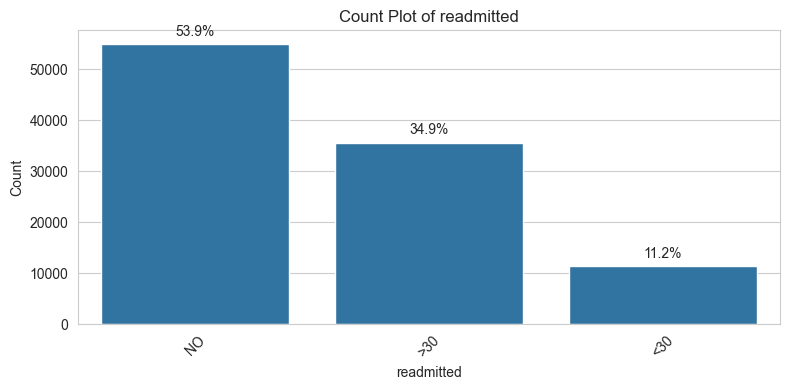

In [11]:
def display_univariate_analysis(dataframe, numerical_cols=None, categorical_cols=None, bins=30):
    """
        This function displays univariate analysis for numerical and categorical columns in the given DataFrame.
        
        Parameters:
        dataframe (pd.DataFrame): The input DataFrame to analyze.
        numerical_cols (list): A list of numerical column names to analyze.
        categorical_cols (list): A list of categorical column names to analyze.
    """

    def annotate_percentages(ax, total_count):
        for patch in ax.patches:
            height = patch.get_height()
            if height == 0:
                continue
            percentage = (height / total_count) * 100
            ax.annotate(
                f'{percentage:.1f}%',
                (patch.get_x() + patch.get_width() / 2, height),
                ha='center',
                va='bottom',
                xytext=(0, 4),
                textcoords='offset points'
            )

    if numerical_cols is None and categorical_cols is None:
        raise ValueError("At least one of numerical_cols or categorical_cols must be provided.")

    if numerical_cols is not None:
        print("✓ Univariate Analysis for Numerical Columns:")
        for col in numerical_cols:
            fig, axes = plt.subplots(1, 2, figsize=(12, 4))

            # Histogram
            sns.histplot(data=dataframe, x=col, bins=bins, kde=True, ax=axes[0])
            axes[0].set_title(f'Distribution of {col}')
            axes[0].set_xlabel(col)

            # Boxplot
            sns.boxplot(data=dataframe, x=col, ax=axes[1])
            axes[1].set_title(f'Boxplot of {col}')
            axes[1].set_xlabel(col)

            plt.tight_layout()
            plt.show()

        print("Summary statistics for numerical columns:")
        display(dataframe[numerical_cols].describe())

    if categorical_cols is not None:
        print("✓ Univariate Analysis for Categorical Columns:")
        for col in categorical_cols:
            non_null = dataframe[col].dropna()
            total = len(non_null)

            # If too many categories, show table instead
            if dataframe[col].nunique(dropna=True) > 10:
                print(f"✓ Showing value counts for {col} (more than 10 unique values):")
                counts = dataframe[col].value_counts(dropna=False)
                percentages = dataframe[col].value_counts(dropna=False, normalize=True) * 100

                summary_df = pd.DataFrame({
                    'count': counts,
                    'percentage (%)': percentages.round(1)
                })

                display(summary_df)
                continue

            plt.figure(figsize=(8, 4))
            ax = sns.countplot(data=dataframe, x=col, order=dataframe[col].value_counts().index)
            plt.title(f'Count Plot of {col}')
            plt.xlabel(col)
            plt.ylabel("Count")

            annotate_percentages(ax, total)

            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()

display_univariate_analysis(df_cleaned, None, [target])

For the interest of this project, we will convert readmitted into:

- 1 = readmitted within 30 days -> "<30"
- 0 = not readmitted within 30 days -> "NO" and ">30"

✓ Target variable 'readmitted' value counts after encoding:


readmitted
0    90409
1    11357
Name: count, dtype: int64

✓ Univariate Analysis for Categorical Columns:


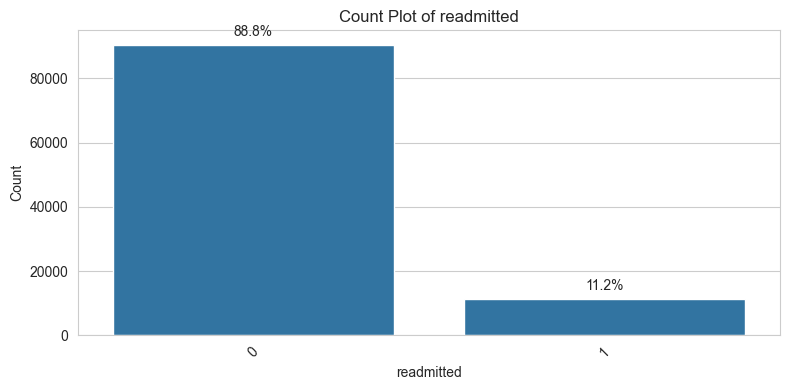

In [12]:
df_cleaned[target] = df_cleaned[target].replace({'<30': 1, '>30': 0, 'NO': 0})
print(f"✓ Target variable '{target}' value counts after encoding:")
display(df_cleaned[target].value_counts())

display_univariate_analysis(df_cleaned, None, [target])

After binarization, the target variable exhibits pronounced class imbalance: 90,409 encounters (88.8%) belong to the negative class (not readmitted within 30 days) while only 11,357 (11.2%) belong to the positive class, yielding an approximate 8:1 ratio. This level of imbalance is typical in hospital readmission datasets, where the majority of discharges do not result in a rapid return.

Left unaddressed, this imbalance will bias most classifiers toward predicting the majority class, inflating accuracy while suppressing recall on the positive class — the very outcome the project is designed to detect. Since the cost of missing a high-risk readmission is greater than the cost of a false positive, standard accuracy is a misleading metric here. AUC-ROC will serve as the primary evaluation metric, supplemented by recall, precision, and F1-score to assess the trade-off directly. At the modeling stage, techniques such as SMOTE, class-weight adjustment, or decision-threshold tuning will be applied to improve sensitivity to the minority class.

### Univariate analysis of the numerical columns

Given that we only have 8 numerical columns, we can do univariate analysis for all of them.

✓ Univariate Analysis for Numerical Columns:


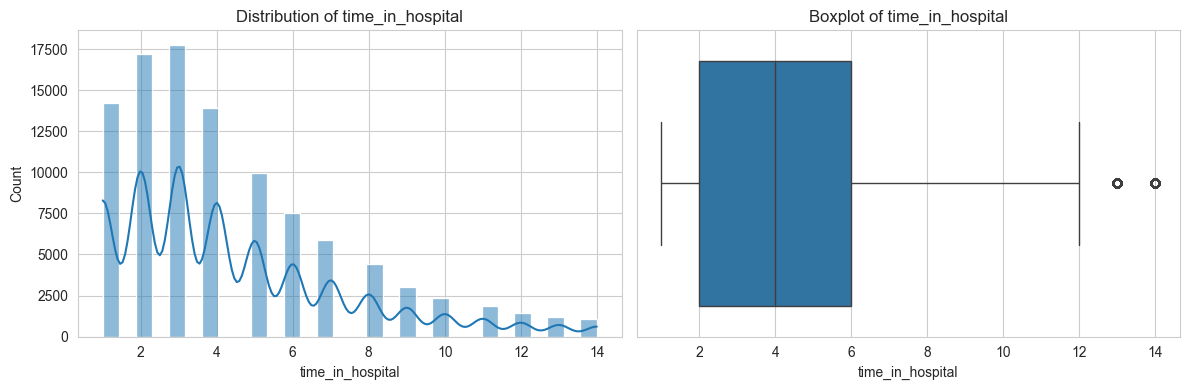

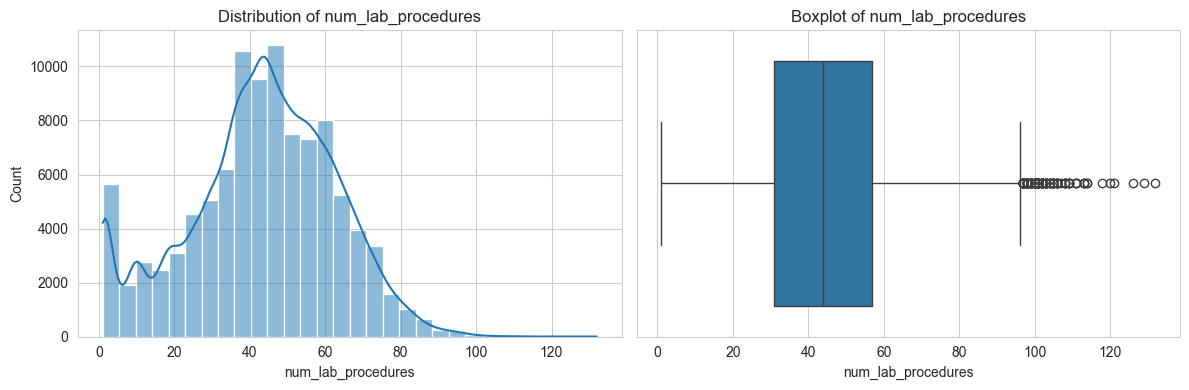

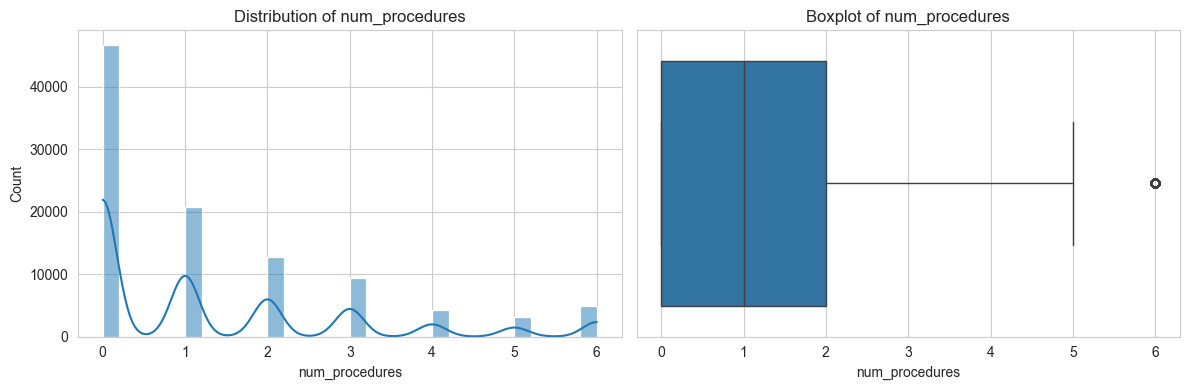

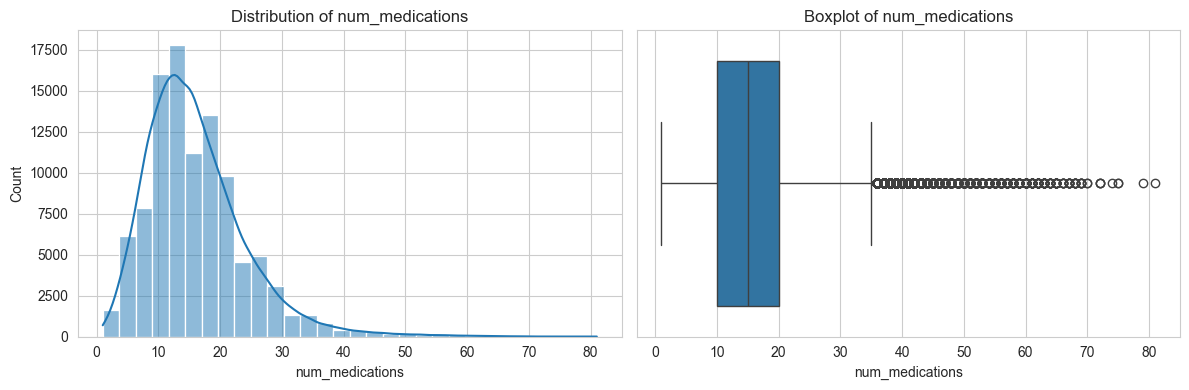

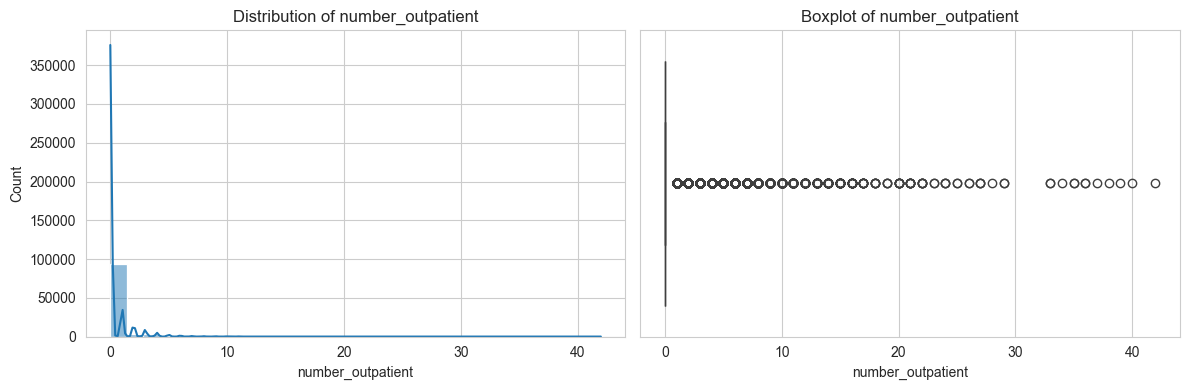

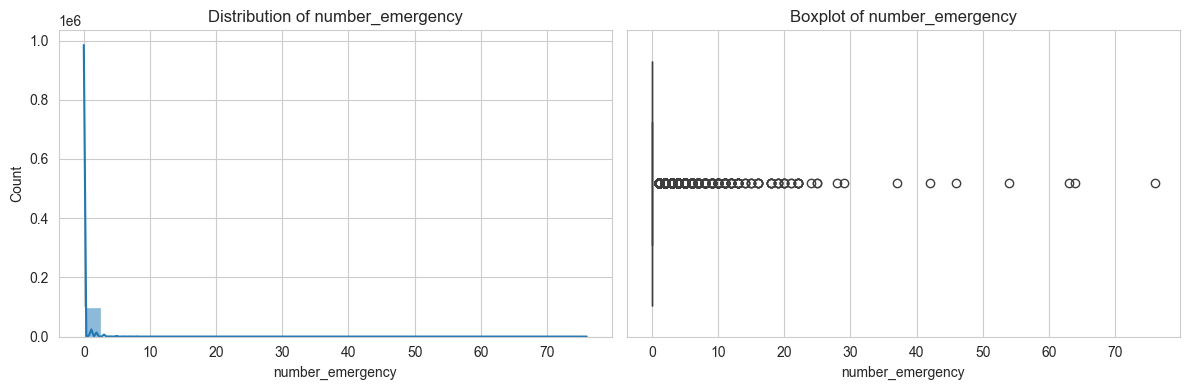

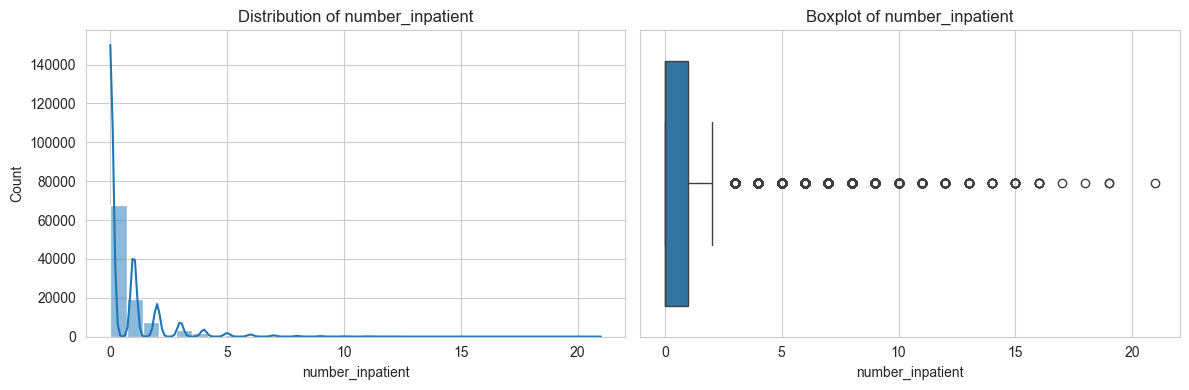

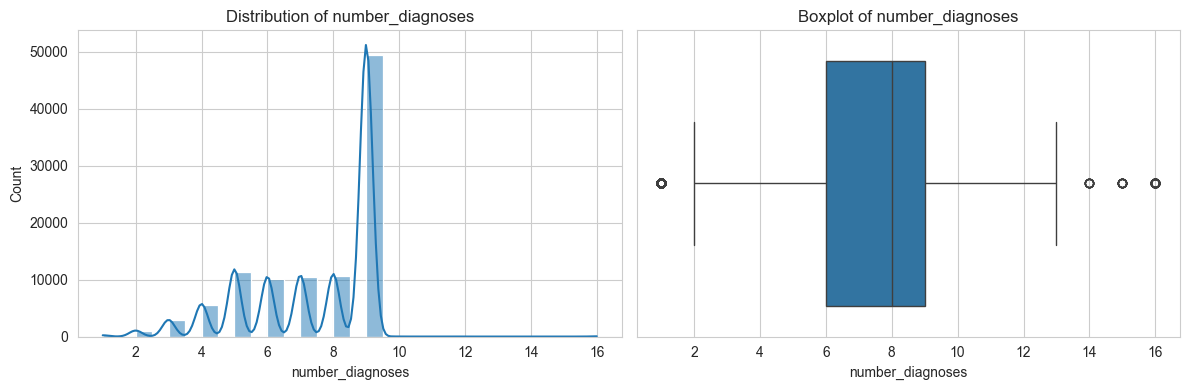

Summary statistics for numerical columns:


,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [13]:
display_univariate_analysis(df_cleaned, numerical_columns)

The eight numerical columns split naturally into two groups based on their distributional behaviour.

**Current-encounter clinical variables** — `time_in_hospital`, `num_lab_procedures`, `num_procedures`, `num_medications`, and `number_diagnoses` — describe the intensity of the index admission itself. Of these, `num_lab_procedures` (mean 43.1, median 44) and `number_diagnoses` (mean 7.4, median 8, IQR 6–9) are the most symmetric and tightly bounded, suggesting relatively uniform measurement practices across encounters. `time_in_hospital` (mean 4.4 days, median 4, range 1–14) and `num_medications` (mean 16.0, median 15, max 81) are moderately right-skewed, with the extreme tail of `num_medications` likely reflecting patients on complex polypharmacy regimens — a clinically meaningful signal for readmission risk. `num_procedures` is similarly right-skewed with a median of 1 and a maximum of 6.

**Prior healthcare utilization variables** — `number_outpatient`, `number_emergency`, and `number_inpatient` — exhibit severe zero-inflation: the median (and both Q1 and Q2) are 0 for all three, yet their maxima reach 42, 76, and 21 respectively. This distributional shape is expected for event-count data in a general hospital population, where most patients have no recorded prior visits in the observation window. The small subset with high prior utilization are likely high-risk, chronically ill patients, making these variables potentially among the most predictive features despite — or because of — their extreme skew.

For tree-based models, these distributions present no preprocessing obstacle. For linear or distance-based models, log1p transformation of the skewed utilization counts (`number_outpatient`, `number_emergency`, `number_inpatient`, and possibly `num_medications`) should be evaluated to prevent the scale disparity from dominating gradient or distance calculations.

### Univariate analysis of the categorical columns

Given that there are 35 categorical columns, we will only analyze key columns. We will focus on demographics, clinical-related group, and treatment status group.

In [14]:
# Group categorical columns into meaningful categories for EDA and feature engineering

demographic_admin_group = [
    'race',
    'gender',
    'age',
    'admission_type_id',
    'discharge_disposition_id',
    'admission_source_id',
    'medical_specialty'
]

clinical_group = [
    'diag_1',
    'diag_2',
    'diag_3',
    'max_glu_serum',
    'A1Cresult'
]

treatment_status_group = [
    'change',
    'diabetesMed',
    'insulin'
]

medication_features_group = [
    col for col in categorical_columns
    if col not in demographic_admin_group + clinical_group + treatment_status_group
]

categorical_groups = {
    'demographic_admin': demographic_admin_group,
    'clinical': clinical_group,
    'treatment_status': treatment_status_group,
    'medication_features': medication_features_group
}

print("✓ Categorical columns grouped into:\n")
for group_name, cols in categorical_groups.items():
    print(f"{group_name} ({len(cols)} columns): {cols}")

✓ Categorical columns grouped into:

demographic_admin (7 columns): ['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'medical_specialty']
clinical (5 columns): ['diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult']
treatment_status (3 columns): ['change', 'diabetesMed', 'insulin']
medication_features (20 columns): ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']


**Demographic Group**

✓ Univariate Analysis for Categorical Columns:


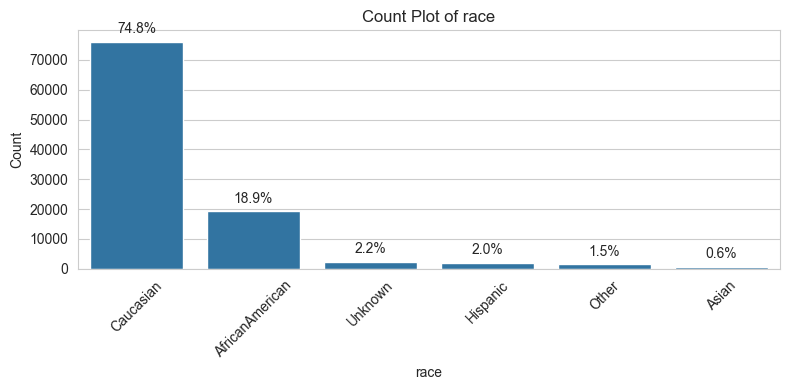

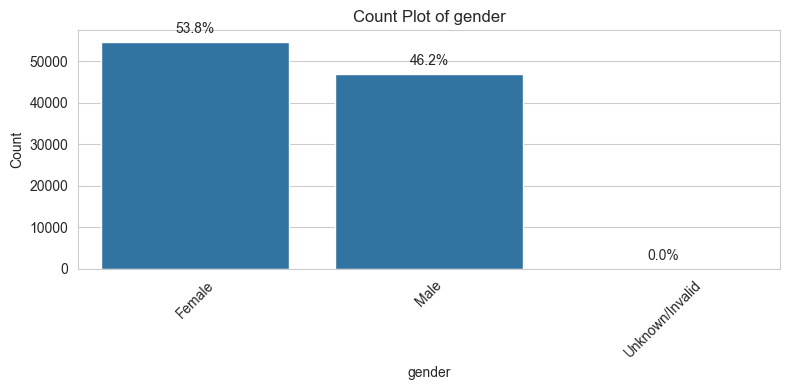

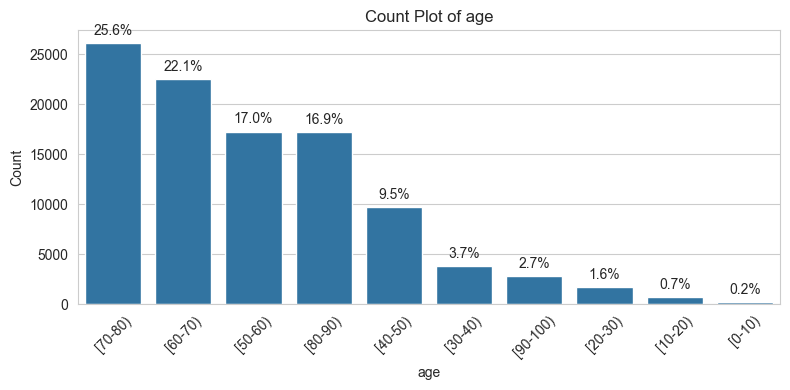

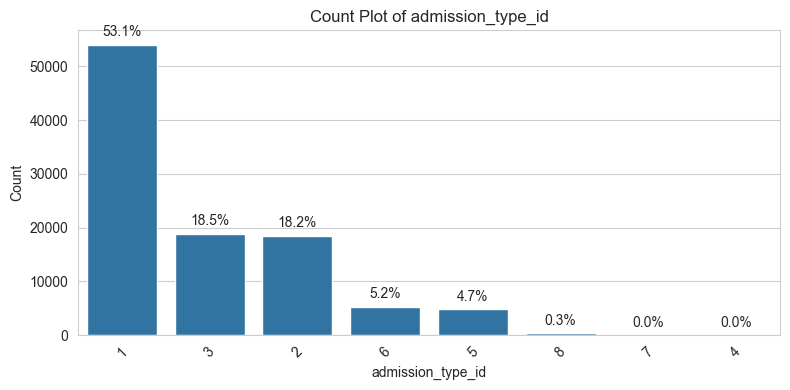

✓ Showing value counts for discharge_disposition_id (more than 10 unique values):


,count,percentage (%)
discharge_disposition_id,,
1,60234,59.2
3,13954,13.7
6,12902,12.7
18,3691,3.6
2,2128,2.1
22,1993,2.0
11,1642,1.6
5,1184,1.2
25,989,1.0


✓ Showing value counts for admission_source_id (more than 10 unique values):


,count,percentage (%)
admission_source_id,,
7,57494,56.5
1,29565,29.1
17,6781,6.7
4,3187,3.1
6,2264,2.2
2,1104,1.1
5,855,0.8
3,187,0.2
20,161,0.2


✓ Showing value counts for medical_specialty (more than 10 unique values):


,count,percentage (%)
medical_specialty,,
Unknown,49949,49.1
InternalMedicine,14635,14.4
Emergency/Trauma,7565,7.4
Family/GeneralPractice,7440,7.3
Cardiology,5352,5.3
Surgery-General,3099,3.0
Nephrology,1613,1.6
Orthopedics,1400,1.4
Orthopedics-Reconstructive,1233,1.2


In [15]:
display_univariate_analysis(df_cleaned, None, categorical_groups['demographic_admin'])

The demographic and administrative features collectively characterise the patient population across these 130 US hospitals and carry meaningful signals for both modeling and fairness evaluation.

**Race.** The dataset is heavily Caucasian-dominated (74.8%), with African American patients forming the next-largest group (18.9%). Hispanic (2.0%), Other (1.5%), and Asian (0.6%) patients combined account for fewer than 5% of encounters. This concentration warrants deliberate attention during fairness analysis: models trained on this distribution risk poor generalisation to underrepresented groups, and differential performance across racial subgroups should be explicitly assessed in the evaluation stage.

**Gender.** The split is moderately skewed toward female patients (53.8% vs 46.2% male). Three records classified as `Unknown/Invalid` are negligible and can be dropped without meaningful data loss.

**Age.** The population skews strongly toward older adults. The [70–80) cohort is the largest (25.6%), followed by [60–70) (22.1%) and [80–90) (16.9%); patients aged 60 and above account for approximately 67% of all encounters. Patients under 40 represent fewer than 6%. This distribution is clinically consistent with the higher prevalence of Type 2 diabetes and comorbidities in older populations. For feature engineering, collapsing the ten bins into broader ordinal bands (e.g., <50, 50–69, 70+) may reduce noise while preserving the clinically meaningful risk gradient. As age is encoded as an ordinal string interval, it will require ordinal encoding or numeric midpoint conversion before use in any linear or distance-based model.

**Admission type.** More than half of encounters are emergency admissions (53.1%, code 1), with elective (18.5%, code 3) and urgent (18.2%, code 2) admissions comprising most of the remainder. Codes 5, 6, and 8 (Not Available, NULL, Not Mapped) account for roughly 10% of records and should be consolidated into a single `'Unknown'` category to avoid leaking administrative artifacts into the model.

**Discharge disposition.** The majority of patients were discharged to home (59.2%, code 1), followed by transfer to a Skilled Nursing Facility (13.7%, code 3) and discharge to home with home health services (12.7%, code 6). With 26 distinct values, this variable has high cardinality and is a strong candidate for grouping into clinically coherent buckets: home discharge, skilled/facility transfer, and other. Importantly, code 11 (Expired, 1.6%) represents patients who died during the encounter and are structurally incapable of readmission. These records represent a potential leakage risk and should be excluded or masked before training to prevent the model from learning a trivially correct negative association.

**Admission source.** Over half of encounters originated from the Emergency Room (56.5%, code 7), with Physician Referral (29.1%, code 1) as the next-largest source. Code 17 (NULL, 6.7%) and minor codes can be folded into an `'Unknown'` or `'Other'` group. ER-sourced admissions are plausibly higher acuity cases, making admission source a useful proxy for illness severity and, by extension, readmission risk.

**Medical specialty.** After the preprocessing step that grouped rare specialties and replaced `'?'` with `'Unknown'`, the `'Unknown'` category is by far the most frequent entry at 49.1%. Among identifiable specialties, Internal Medicine (14.4%), Emergency/Trauma (7.4%), Family/General Practice (7.3%), and Cardiology (5.3%) are the most prevalent. The high proportion of unknowns limits this feature's standalone utility, but specialty may still contribute signal when combined with other variables. A useful engineering decision would be to derive a binary `specialty_known` indicator alongside the grouped specialty label, separating absence of information from meaningful category membership.

**Clinical Group**

✓ Univariate Analysis for Categorical Columns:
✓ Showing value counts for diag_1 (more than 10 unique values):


,count,percentage (%)
diag_1,,
428,6862,6.7
414,6581,6.5
786,4016,3.9
410,3614,3.6
486,3508,3.4
...,...,...
833,1,0.0
391,1,0.0
690,1,0.0


✓ Showing value counts for diag_2 (more than 10 unique values):


,count,percentage (%)
diag_2,,
276,6752,6.6
428,6662,6.5
250,6071,6.0
427,5036,4.9
401,3736,3.7
...,...,...
123,1,0.0
884,1,0.0
V60,1,0.0


✓ Showing value counts for diag_3 (more than 10 unique values):


,count,percentage (%)
diag_3,,
250,11555,11.4
401,8289,8.1
276,5175,5.1
428,4577,4.5
427,3955,3.9
...,...,...
14,1,0.0
750,1,0.0
370,1,0.0


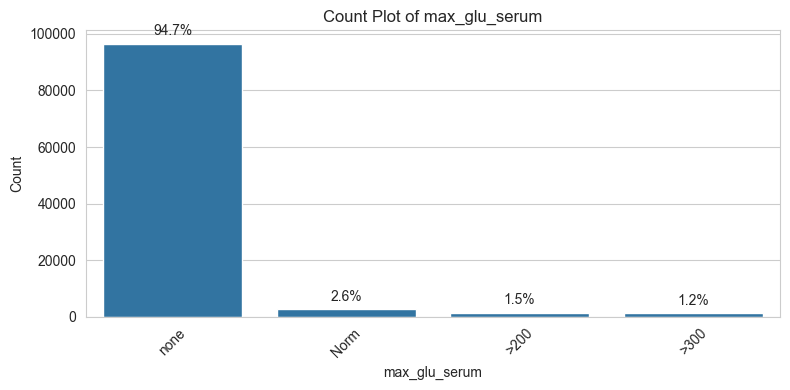

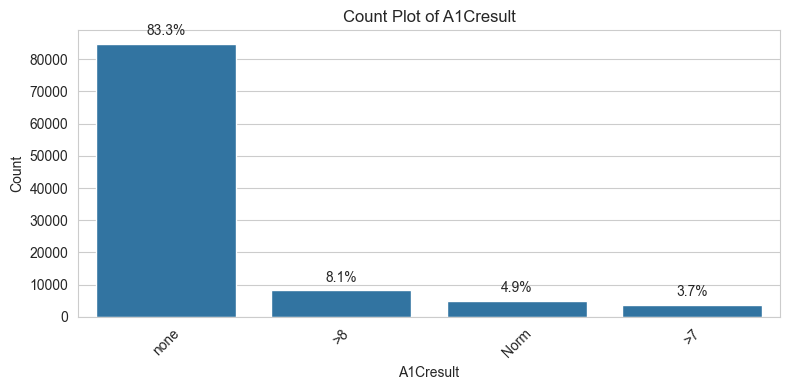

In [16]:
display_univariate_analysis(df_cleaned, None, categorical_groups['clinical'])

The clinical group comprises three diagnosis codes (`diag_1`, `diag_2`, `diag_3`) and two laboratory test result indicators (`max_glu_serum`, `A1Cresult`). Together, these features directly characterise the patient's medical condition at the time of admission and carry strong potential predictive signal for readmission risk.

**Diagnosis codes (diag_1, diag_2, diag_3).** All three diagnosis columns use ICD-9 coding and exhibit extremely high cardinality: 717, 749, and 790 unique values respectively. No single code dominates — the most frequent primary diagnosis (ICD-9 428, heart failure) accounts for only 6.7% of records, and the top five codes combined cover fewer than 27% of encounters. This degree of fragmentation means raw ICD-9 codes cannot be used directly in most models without incurring severe sparsity or cardinality penalties. The standard approach is to map codes to higher-level clinical chapters (e.g., circulatory, respiratory, diabetes-related, musculoskeletal). Cardiovascular codes (428 heart failure, 414 coronary artery disease, 410 acute MI) dominate `diag_1`, consistent with the known comorbidity burden in the diabetic inpatient population. Diabetes-specific and metabolic codes appear more strongly in secondary and tertiary positions — notably ICD-9 250 is the single most frequent code in `diag_3` (11.4%), suggesting that while diabetes is the defining chronic condition, it is often not the primary reason for the admission.

**Glucose serum test (max_glu_serum).** The overwhelming majority of encounters — 94.7% — have a value of `none`, meaning no serum glucose test was ordered during the stay. Among the 5.3% where the test was performed, results skew toward elevated readings: `>200` (1.5%) and `>300` (1.2%) together exceed the `Normal` category (2.6%). This near-universal absence is itself clinically informative: it may indicate that most admissions were not primarily metabolic crises, or that glucose monitoring practices varied widely across the 130 contributing hospitals. Because the untested state dominates, this feature will have limited discriminative power in its raw form. Encoding `none` as a binary `glucose_tested` flag and retaining the measured level as a separate ordinal feature will preserve the signal from the small but potentially high-risk tested subgroup.

**HbA1c test result (A1Cresult).** Similarly, 83.3% of encounters have no HbA1c result recorded. Among those tested, poorly controlled results are the most common outcome: `>8` (8.1%) exceeds both `Normal` (<7%, 4.9%) and borderline `>7` (3.7%). This pattern is clinically expected — HbA1c tends to be ordered precisely when glycaemic control is under active review, so the tested subgroup over-represents patients with known management challenges. The `>8` category may carry a meaningful readmission signal, but this requires bivariate confirmation. As with `max_glu_serum`, deriving a binary `A1C_tested` indicator alongside the categorical result will prevent the large `none` mass from dominating encoding and obscuring the predictive value of the measured outcomes.

**Treatment Status Group**

✓ Univariate Analysis for Categorical Columns:


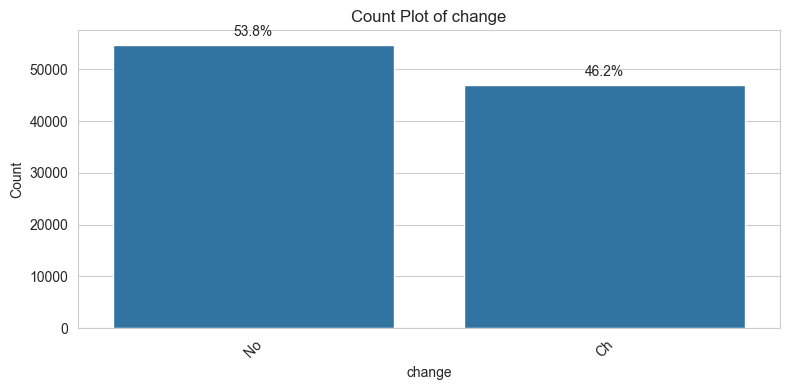

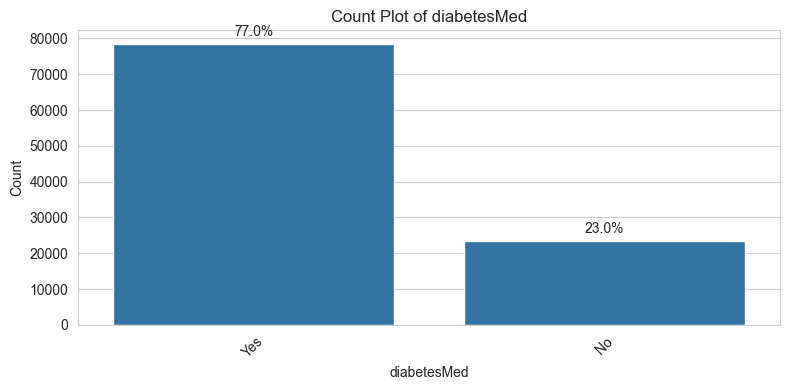

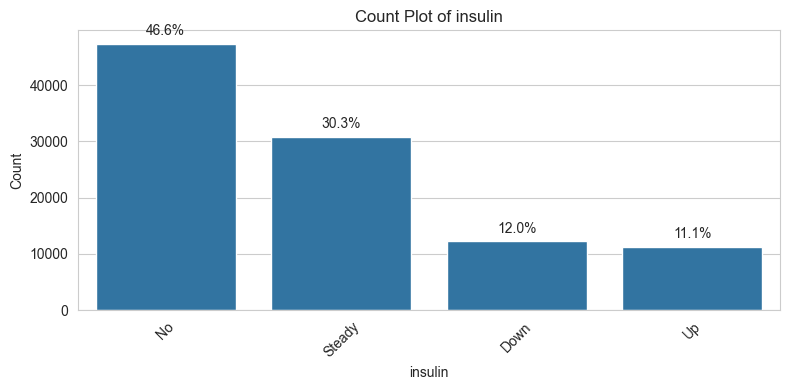

In [17]:
display_univariate_analysis(df_cleaned, None, categorical_groups['treatment_status'])

The treatment status group captures the state of the patient's diabetes management at the time of the encounter: whether any medication was changed (`change`), whether any diabetes medication was prescribed at all (`diabetesMed`), and the specific dosage trajectory of insulin (`insulin`). All three features are directly therapy-related and may carry meaningful signal for readmission risk, since poor or unstable glycaemic management is a known driver of return visits.

**Medication change (change).** The dataset is nearly evenly split between encounters where a medication change occurred (`Ch`, 46.2%) and those where it did not (`No`, 53.8%). This near-balance is noteworthy: a medication change during admission is typically a clinical response to suboptimal control, meaning the `Ch` group may contain patients with more poorly managed or actively deteriorating diabetes. At the same time, a change could reflect a positive adjustment reducing readmission risk. The binary distribution means this feature is straightforward to encode and will not suffer from class imbalance, but its directional relationship with the target requires bivariate investigation before assuming a sign.

**Diabetes medication prescribed (diabetesMed).** A clear majority of encounters (77.0%) had at least one diabetes medication prescribed, versus 23.0% without. The large `Yes` majority is expected given the nature of the dataset: these are hospitalised diabetic patients, and most would be on active pharmacotherapy. The minority `No` group may represent newly diagnosed patients, those managed by diet alone, or cases where medication was withheld for clinical reasons. Simple binary encoding (`Yes`/`No` → 1/0) is appropriate. Despite the imbalance, this feature may have limited standalone predictive power given how dominant the `Yes` category is across the full cohort; its contribution is more likely to emerge in interaction with other treatment variables.

**Insulin dosage trajectory (insulin).** With four categories, `insulin` is the most granular of the three features. Nearly half of encounters had no insulin prescribed (`No`, 46.6%). Among those on insulin, the majority maintained a steady dose (`Steady`, 30.3%), while dose reductions (`Down`, 12.0%) and increases (`Up`, 11.1%) were roughly equal in prevalence. The balance between `Down` and `Up` suggests that dose titration was not systematically directional across the population. For modeling, this feature is a candidate for ordinal encoding that encodes clinical change magnitude — one reasonable ordering would be `No` < `Steady` < `Down` or `Up`, though `Down` and `Up` may warrant separate treatment since both represent instability relative to `Steady`. Alternatively, deriving a binary `insulin_adjusted` flag (collapsing `Down` and `Up` into a single change indicator) would simplify encoding while preserving the key distinction between stable and actively modified regimens.

### Bivariate analysis

The bivariate analysis will examine the relationship between the target variable (`readmitted`) and key features — covering all eight numerical columns and a curated selection of categorical columns. For categorical features, selection was guided by the univariate findings: variables with clinically meaningful distributions, sufficient category coverage, or known risk associations were prioritised. The three high-cardinality diagnosis columns (`diag_1`, `diag_2`, `diag_3`) are excluded at this stage — with 717–790 unique ICD-9 codes each, they require chapter-level grouping before any meaningful bivariate comparison is possible.

**Demographic & administrative features:**

- **`race`** — Essential for examining differential readmission rates across racial groups and for downstream fairness evaluation; the heavy Caucasian skew (74.8%) makes disparate-impact assessment mandatory.
- **`gender`** — The near-even split (53.8% female / 46.2% male) provides a clean, interpretable comparison of sex-based readmission differences.
- **`age`** — Strong a priori candidate: ~67% of patients are aged 60+ and readmission risk is expected to follow a monotonic age gradient in this diabetic inpatient population.
- **`admission_type_id`** — Emergency admissions dominate (53.1%) and represent higher-acuity encounters; comparing readmission rates between emergency, urgent, and elective admissions tests whether admission severity is a meaningful risk differentiator.
- **`discharge_disposition_id`** — The univariate analysis flagged code 11 (Expired, 1.6%) as a leakage risk; bivariate analysis is needed to confirm this concern and to assess whether discharge destination (home vs. facility transfer) separates readmission risk.
- **`admission_source_id`** — ER-sourced admissions (56.5%) were identified as a plausible proxy for illness severity; quantifying their readmission rate relative to physician referrals and other sources will validate this hypothesis.
- **`medical_specialty`** — Included with a caveat: 49.1% of records have `Unknown` specialty, so the analysis will focus on the known specialties and a `specialty_known` binary flag should be evaluated alongside the grouped label.

**Clinical features:**

- **`max_glu_serum`** — Included despite 94.7% `none` values; the small tested subgroup skews toward elevated readings (`>200`, `>300`) that may carry a clinically meaningful readmission signal worth quantifying.
- **`A1Cresult`** — Similarly included despite 83.3% `none`; the `>8` group (8.1%) represents poorly controlled diabetes and is the most clinically actionable category to compare against the target.

**Treatment status features:**

- **`change`** — Near-even split (53.8% / 46.2%) makes this a strong candidate; whether in-hospital medication adjustment correlates positively or negatively with readmission is an open and important clinical question.
- **`diabetesMed`** — Included to confirm whether active pharmacotherapy status differentiates readmission risk, acknowledging that the dominant `Yes` category (77.0%) may limit the observable effect size.
- **`insulin`** — The most granular treatment variable with four categories; particular interest lies in whether dose adjustments (`Up`, `Down`) are associated with higher readmission compared to stable (`Steady`) or no-insulin (`No`) patients.

## Bivariate Analysis: Numerical Features vs Target

### time_in_hospital

,0,1
mean,4.349,4.768
median,4.000,4.000


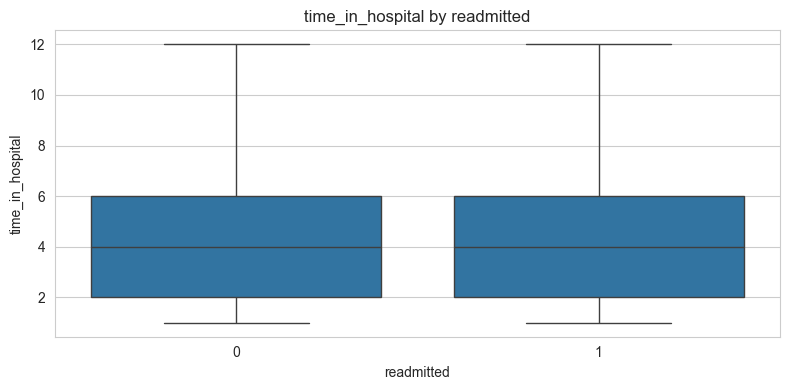

### num_lab_procedures

,0,1
mean,42.954,44.226
median,44.000,45.000


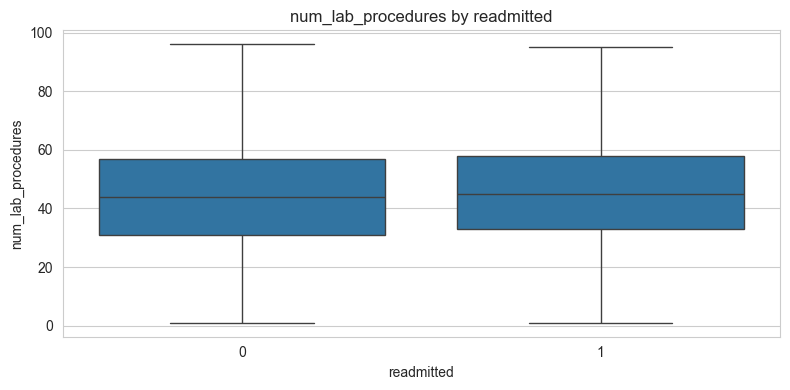

### num_procedures

**Auto plot selection:** `num_procedures` is zero-inflated (45.8% zeros), so a histogram is used.

,0,1
mean,1.347,1.281
median,1.000,1.000


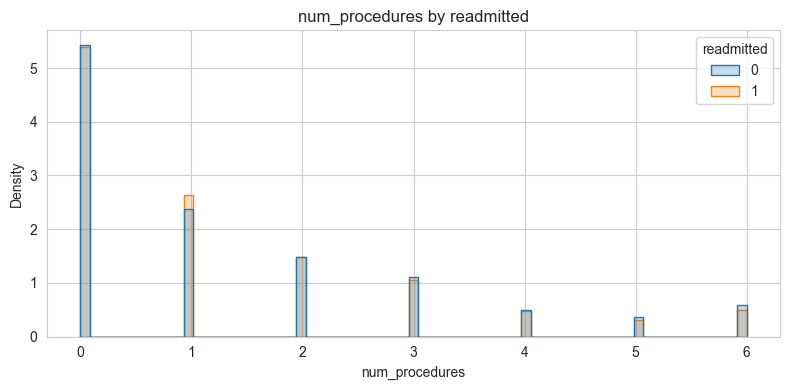

### num_medications

,0,1
mean,15.911,16.903
median,15.000,16.000


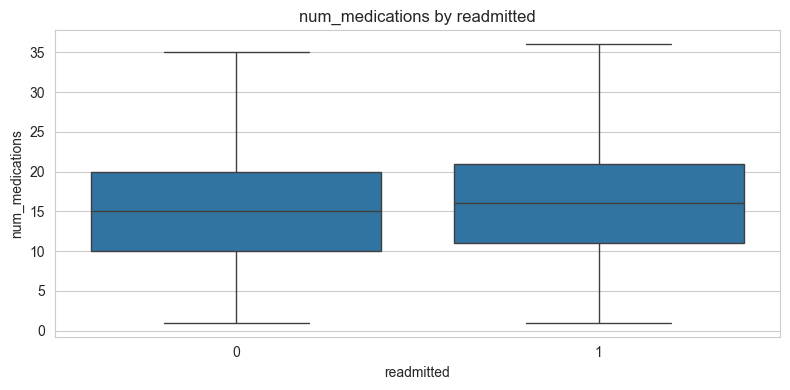

### number_outpatient

**Auto plot selection:** `number_outpatient` is zero-inflated (83.6% zeros), so a histogram is used.

,0,1
mean,0.361,0.437
median,0.000,0.000


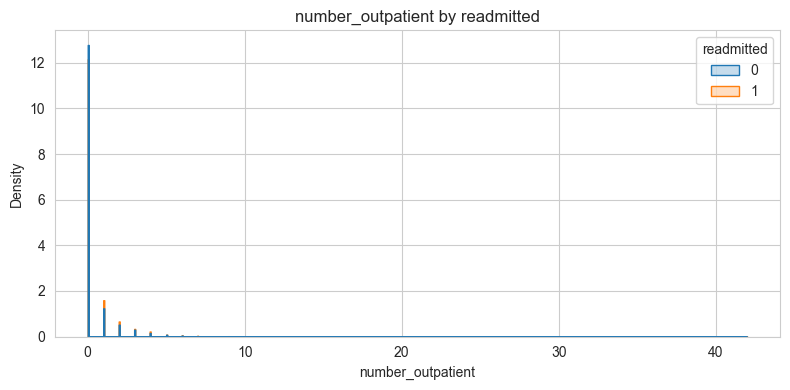

### number_emergency

**Auto plot selection:** `number_emergency` is zero-inflated (88.8% zeros), so a histogram is used.

,0,1
mean,0.178,0.357
median,0.000,0.000


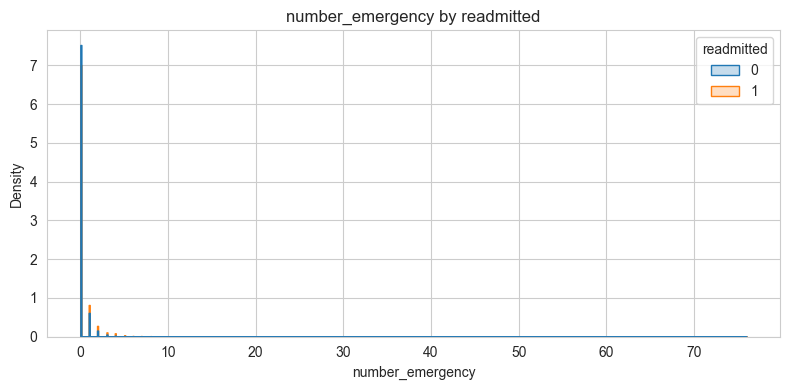

### number_inpatient

**Auto plot selection:** `number_inpatient` is zero-inflated (66.5% zeros), so a histogram is used.

,0,1
mean,0.562,1.224
median,0.000,0.000


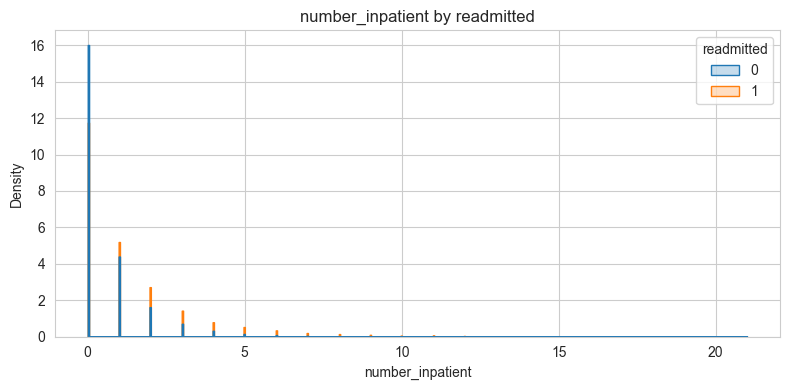

### number_diagnoses

,0,1
mean,7.389,7.693
median,8.000,9.000


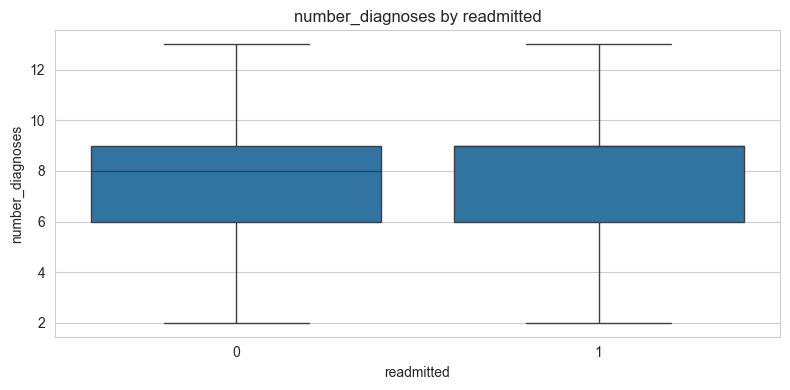

## Numerical Summary Table

,mean_0,mean_1,median_0,median_1,diff,pct_diff,zero_ratio
feature,,,,,,,
time_in_hospital,4.349,4.768,4.0,4.0,0.419,9.634,0.00
num_lab_procedures,42.954,44.226,44.0,45.0,1.272,2.961,0.00
num_procedures,1.347,1.281,1.0,1.0,-0.066,-4.900,45.84
num_medications,15.911,16.903,15.0,16.0,0.992,6.235,0.00
number_outpatient,0.361,0.437,0.0,0.0,0.076,21.053,83.55
number_emergency,0.178,0.357,0.0,0.0,0.179,100.562,88.81
number_inpatient,0.562,1.224,0.0,0.0,0.662,117.794,66.46
number_diagnoses,7.389,7.693,8.0,9.0,0.304,4.114,0.00


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown


def display_bivariate_analysis(
    dataframe,
    target_col,
    numerical_cols=None,
    categorical_cols=None,
    positive_class=1,
    negative_class=0,
    top_n_categories=10,
    default_numeric_plot="box",
    show_fliers=False,
    zero_inflation_threshold=0.30,
    figsize=(8, 4)
):
    """
    Display notebook-friendly bivariate analysis between selected features and a target variable.

    This function is designed for exploratory data analysis inside a Jupyter notebook.
    It compares numerical and categorical features against a target variable and presents
    results in a format that is easier to interpret for preprocessing, feature engineering,
    and modeling decisions.

    For numerical features, the function:
    - computes class-wise mean and median
    - shows absolute and percentage differences between the target classes
    - visualizes each feature against the target
    - can automatically switch to histogram-based plots for zero-inflated variables,
    where standard boxplots are often hard to interpret

    For categorical features, the function:
    - displays count tables
    - displays row-normalized percentage tables
    - optionally groups rare categories into an "Other" bucket for readability
    - visualizes category-level differences across the target classes

    This helper is especially useful in structured/tabular machine learning projects where
    the goal is not only to visualize relationships, but also to identify practical next
    steps such as retaining, grouping, transforming, encoding, or deprioritizing features.

    Parameters:
    -----------
    dataframe : pd.DataFrame
        Input dataframe containing the features and target column.

    target_col : str
        Name of the target variable column.

    numerical_cols : list of str, optional
        List of numerical columns to analyze against the target variable.
        If provided, the function will generate summary statistics and plots
        for each numerical feature.

    categorical_cols : list of str, optional
        List of categorical columns to analyze against the target variable.
        If provided, the function will generate contingency tables and plots
        for each categorical feature.

    positive_class : int, str, default=1
        Label representing the positive class in the target variable.
        Used when computing class differences for numerical summaries.

    negative_class : int, str, default=0
        Label representing the negative/reference class in the target variable.
        Used when computing class differences for numerical summaries.

    top_n_categories : int, default=10
        Maximum number of categories to display for high-cardinality categorical variables.
        Categories outside the top N most frequent values are grouped into "Other"
        for readability in tables and plots.

    default_numeric_plot : {'box', 'violin', 'hist'}, default='box'
        Default plot type to use for numerical variables unless automatic
        zero-inflation detection selects a histogram instead.

    show_fliers : bool, default=False
        Whether to display outlier points in boxplots.
        Setting this to False is often helpful when variables are highly skewed
        or contain extreme values that compress the box and whiskers.

    zero_inflation_threshold : float, default=0.30
        Threshold used to detect zero-inflated numerical variables.
        If the proportion of zero values in a numerical feature is greater than
        or equal to this threshold, the function may use a histogram instead of
        the default numeric plot, since boxplots are often less informative for
        heavily zero-inflated features.

    figsize : tuple, default=(8, 4)
        Figure size used for the generated plots.

    Returns:
    --------
    None
        This function is intended for notebook display and reporting.
        It primarily presents outputs directly in the notebook rather than
        returning processed objects for downstream use.

    Example:
    --------
    >>> display_bivariate_analysis(
    ...     dataframe=df_cleaned,
    ...     target_col='readmitted_binary',
    ...     numerical_cols=[
    ...         'time_in_hospital',
    ...         'num_medications',
    ...         'number_emergency',
    ...         'number_inpatient'
    ...     ],
    ...     default_numeric_plot='box',
    ...     show_fliers=False
    ... )

    >>> display_bivariate_analysis(
    ...     dataframe=df_cleaned,
    ...     target_col='readmitted_binary',
    ...     categorical_cols=[
    ...         'race',
    ...         'gender',
    ...         'age',
    ...         'A1Cresult',
    ...         'insulin',
    ...         'diabetesMed'
    ...     ],
    ...     top_n_categories=10
    ... )

    Notes:
    ------
    - This function is intended for exploratory analysis, not hypothesis testing.
    - Mean and median comparisons help reveal class separation, but they do not
    establish statistical significance on their own.
    - Percentage differences can appear very large when the baseline mean is close
    to zero, so they should always be interpreted together with absolute differences.
    - Zero-inflated healthcare utilization variables (for example, prior emergency
    or inpatient visits) often benefit from histogram-based visualization.
    - Grouping rare categorical levels into "Other" improves readability, but this
    grouping is intended for EDA/display purposes and should be reviewed carefully
    before applying the same strategy in final preprocessing.
    - If the target variable is highly imbalanced, visual differences should be
    interpreted alongside class proportions and later validated during modeling.
    """

    if numerical_cols is None and categorical_cols is None:
        raise ValueError("At least one of numerical_cols or categorical_cols must be provided.")

    # -----------------------------
    # NUMERICAL COLUMNS
    # -----------------------------
    if numerical_cols is not None:
        display(Markdown("## Bivariate Analysis: Numerical Features vs Target"))

        summary_rows = []

        for col in numerical_cols:
            display(Markdown(f"### {col}"))

            grouped = dataframe.groupby(target_col)[col].agg(["mean", "median"]).round(3)

            neg_mean = grouped.loc[negative_class, "mean"] if negative_class in grouped.index else np.nan
            pos_mean = grouped.loc[positive_class, "mean"] if positive_class in grouped.index else np.nan
            neg_median = grouped.loc[negative_class, "median"] if negative_class in grouped.index else np.nan
            pos_median = grouped.loc[positive_class, "median"] if positive_class in grouped.index else np.nan

            diff = pos_mean - neg_mean if pd.notnull(pos_mean) and pd.notnull(neg_mean) else np.nan
            pct_diff = ((diff / neg_mean) * 100) if pd.notnull(neg_mean) and neg_mean != 0 else np.nan

            zero_ratio = (dataframe[col] == 0).mean()

            # Auto-select plot type
            if zero_ratio >= zero_inflation_threshold:
                numeric_plot = "hist"
                display(Markdown(
                    f"**Auto plot selection:** `{col}` is zero-inflated "
                    f"({zero_ratio:.1%} zeros), so a histogram is used."
                ))
            else:
                numeric_plot = default_numeric_plot

            detail_table = pd.DataFrame({
                negative_class: [neg_mean, neg_median],
                positive_class: [pos_mean, pos_median]
            }, index=["mean", "median"])

            display(detail_table)

            summary_rows.append({
                "feature": col,
                f"mean_{negative_class}": round(neg_mean, 3),
                f"mean_{positive_class}": round(pos_mean, 3),
                f"median_{negative_class}": round(neg_median, 3),
                f"median_{positive_class}": round(pos_median, 3),
                "diff": round(diff, 3) if pd.notnull(diff) else np.nan,
                "pct_diff": round(pct_diff, 3) if pd.notnull(pct_diff) else np.nan,
                "zero_ratio": round(zero_ratio * 100, 2)
            })

            plt.figure(figsize=figsize)

            if numeric_plot == "box":
                sns.boxplot(
                    data=dataframe,
                    x=target_col,
                    y=col,
                    showfliers=show_fliers
                )

            elif numeric_plot == "violin":
                sns.violinplot(
                    data=dataframe,
                    x=target_col,
                    y=col,
                    cut=0
                )

            elif numeric_plot == "hist":
                sns.histplot(
                    data=dataframe,
                    x=col,
                    hue=target_col,
                    kde=False,
                    stat="density",
                    common_norm=False,
                    element="step"
                )

            else:
                raise ValueError("default_numeric_plot must be 'box', 'violin', or 'hist'")

            plt.title(f"{col} by {target_col}")
            plt.xlabel(col if numeric_plot == "hist" else target_col)
            plt.ylabel("Density" if numeric_plot == "hist" else col)
            plt.tight_layout()
            plt.show()

        summary_df = pd.DataFrame(summary_rows).set_index("feature")

        display(Markdown("## Numerical Summary Table"))
        display(summary_df)

    # -----------------------------
    # CATEGORICAL COLUMNS
    # -----------------------------
    if categorical_cols is not None:
        display(Markdown("## Bivariate Analysis: Categorical Features vs Target"))

        for col in categorical_cols:
            display(Markdown(f"### {col}"))

            temp_df = dataframe[[col, target_col]].copy()

            # Convert to string for display/grouping safety
            temp_df[col] = temp_df[col].astype("string")

            value_counts = temp_df[col].value_counts(dropna=False)

            if len(value_counts) > top_n_categories:
                top_categories = value_counts.head(top_n_categories).index
                temp_df[col] = temp_df[col].where(temp_df[col].isin(top_categories), other="Other")

            count_table = pd.crosstab(temp_df[col], temp_df[target_col])
            pct_table = (pd.crosstab(temp_df[col], temp_df[target_col], normalize="index") * 100).round(2)

            display(Markdown("**Count Table**"))
            display(count_table)

            display(Markdown("**Row Percentage Table**"))
            display(pct_table)

            plot_df = pct_table.reset_index().melt(
                id_vars=col,
                var_name=target_col,
                value_name="percentage"
            )

            plt.figure(figsize=(max(figsize[0], 10), figsize[1] + 1))
            sns.barplot(
                data=plot_df,
                x=col,
                y="percentage",
                hue=target_col
            )
            plt.title(f"{col} vs {target_col} (Row %)")
            plt.xlabel(col)
            plt.ylabel("Percentage")
            plt.xticks(rotation=45, ha="right")
            plt.tight_layout()
            plt.show()

display_bivariate_analysis(df_cleaned, target, numerical_columns)

The summary table and visualisations reveal a clear split between features with meaningful separation across the two readmission classes and those that are effectively flat. Note that four features crossed the 30% zero-inflation threshold and were automatically displayed as density histograms rather than boxplots: `number_outpatient` (83.6% zeros), `number_emergency` (88.8%), `number_inpatient` (66.5%), and `num_procedures` (45.8%).

**Prior utilisation variables dominate.** `number_inpatient` and `number_emergency` are the strongest numerical differentiators by a wide margin. Patients readmitted within 30 days had a mean prior inpatient visit count 117.9% higher than non-readmitted patients (0.562 vs 1.224), and a mean prior emergency visit count 100.6% higher (0.178 vs 0.357). Given that 66.5% and 88.8% of values in these columns are zero respectively, the absolute differences are modest in magnitude, but the relative signal is substantial and persistent — and the histogram plots confirm that readmitted patients have a visibly heavier right tail on the non-zero portion of both distributions. `number_outpatient` shows a more moderate 21.1% relative difference (0.361 vs 0.437) despite 83.6% zero inflation. Taken together, the prior utilisation trio tells a coherent clinical story: frequent prior hospitalisations and emergency visits are strong markers of high-acuity, poorly controlled disease — exactly the patient profile associated with rapid readmission.

**Current-encounter variables show weak but consistent trends.** `time_in_hospital` is 9.6% higher on average for readmitted patients (4.349 vs 4.768 days), and `num_medications` is 6.2% higher (15.9 vs 16.9). Both suggest that readmitted patients tend to have more complex and resource-intensive admissions, but neither column is zero-inflated (zero ratio = 0.0% for both), so the boxplots faithfully represent the full distribution — and the spreads overlap heavily. `number_diagnoses` (+4.1%) and `num_lab_procedures` (+3.0%) show only marginal mean differences and essentially identical medians, with next to no zero-inflation. These features will likely contribute minimal standalone signal in any model.

**`num_procedures` is the only feature trending in the opposite direction**, with readmitted patients averaging 4.9% fewer procedures than non-readmitted patients (1.347 vs 1.281). Its 45.8% zero ratio triggered histogram display; the density plots show very similar distributions between classes, with the slight negative direction most plausibly explained by the acuity profile of readmitted patients — those at highest risk may be too unstable for elective or planned procedures, or procedure-heavy encounters may disproportionately represent surgical cases with lower baseline readmission rates.

**Modeling implications.** The prior utilisation trio (`number_inpatient`, `number_emergency`, `number_outpatient`) should be treated as high-priority features. Their extreme zero inflation suggests that a binary `had_prior_inpatient` flag — and analogous flags for emergency and outpatient — may capture much of the separating signal cleanly alongside the raw count. For linear models, log1p transformation will compress the long right tail; for tree-based models, raw values are usable as-is. The current-encounter variables contribute modest additive signal and should be retained, but their limited marginal discriminability means the model will rely on them only in combination with stronger predictors. `num_procedures` is unlikely to be a meaningful predictor in its current form and may perform best as a binary `had_procedures` flag.

## Bivariate Analysis: Categorical Features vs Target

### race

**Count Table**

readmitted,0,1
race,,
AfricanAmerican,17055,2155
Asian,576,65
Caucasian,67507,8592
Hispanic,1825,212
Other,1361,145
Unknown,2085,188


**Row Percentage Table**

readmitted,0,1
race,,
AfricanAmerican,88.78,11.22
Asian,89.86,10.14
Caucasian,88.71,11.29
Hispanic,89.59,10.41
Other,90.37,9.63
Unknown,91.73,8.27


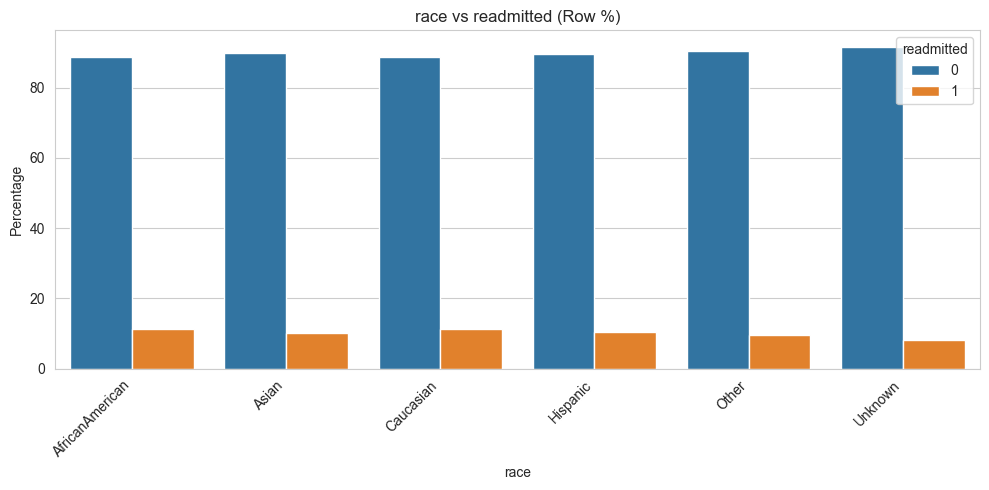

### gender

**Count Table**

readmitted,0,1
gender,,
Female,48556,6152
Male,41850,5205
Unknown/Invalid,3,0


**Row Percentage Table**

readmitted,0,1
gender,,
Female,88.75,11.25
Male,88.94,11.06
Unknown/Invalid,100.00,0.00


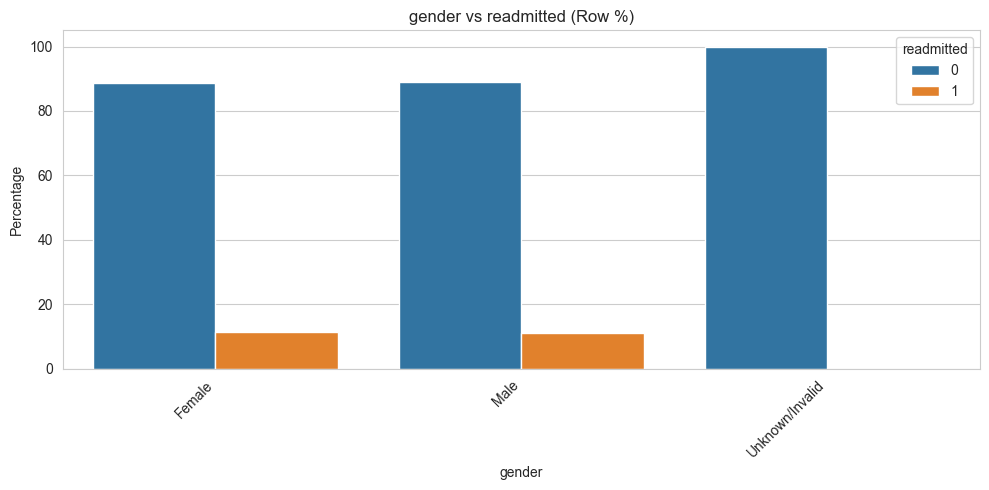

### age

**Count Table**

readmitted,0,1
age,,
[0-10),158,3
[10-20),651,40
[20-30),1421,236
[30-40),3351,424
[40-50),8658,1027
[50-60),15588,1668
[60-70),19981,2502
[70-80),22999,3069
[80-90),15119,2078


**Row Percentage Table**

readmitted,0,1
age,,
[0-10),98.14,1.86
[10-20),94.21,5.79
[20-30),85.76,14.24
[30-40),88.77,11.23
[40-50),89.40,10.60
[50-60),90.33,9.67
[60-70),88.87,11.13
[70-80),88.23,11.77
[80-90),87.92,12.08


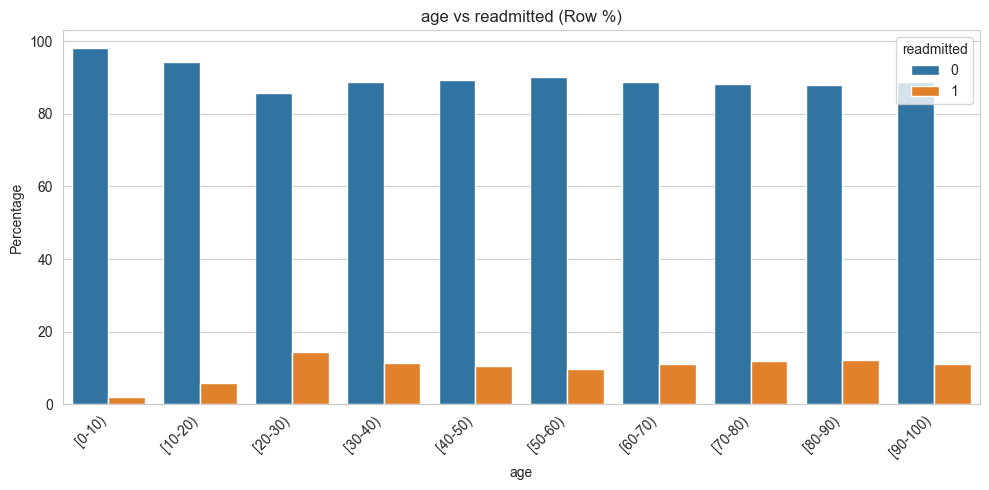

### admission_type_id

**Count Table**

readmitted,0,1
admission_type_id,,
1,47769,6221
2,16414,2066
3,16908,1961
4,9,1
5,4290,495
6,4705,586
7,21,0
8,293,27


**Row Percentage Table**

readmitted,0,1
admission_type_id,,
1,88.48,11.52
2,88.82,11.18
3,89.61,10.39
4,90.00,10.00
5,89.66,10.34
6,88.92,11.08
7,100.00,0.00
8,91.56,8.44


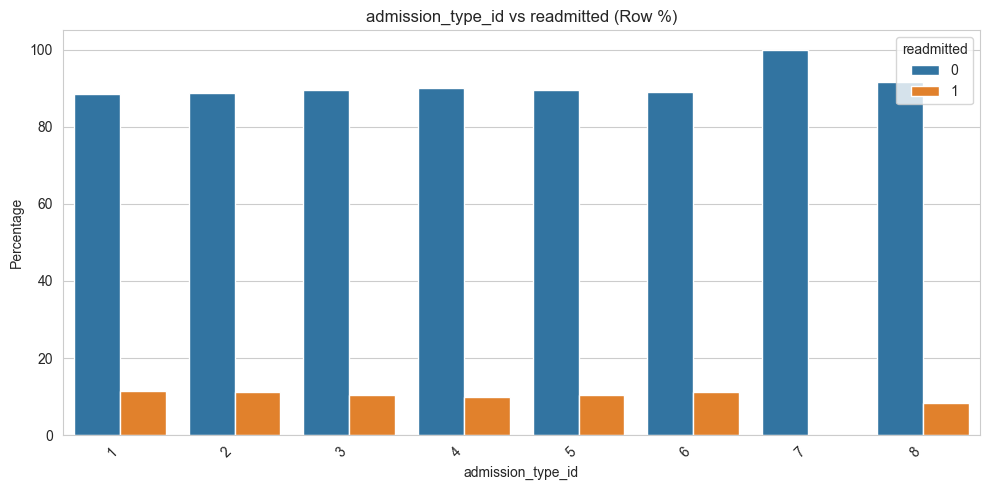

### discharge_disposition_id

**Count Table**

readmitted,0,1
discharge_disposition_id,,
1,54632,5602
11,1642,0
18,3232,459
2,1786,342
22,1441,552
25,897,92
3,11908,2046
4,711,104
5,937,247


**Row Percentage Table**

readmitted,0,1
discharge_disposition_id,,
1,90.70,9.30
11,100.00,0.00
18,87.56,12.44
2,83.93,16.07
22,72.30,27.70
25,90.70,9.30
3,85.34,14.66
4,87.24,12.76
5,79.14,20.86


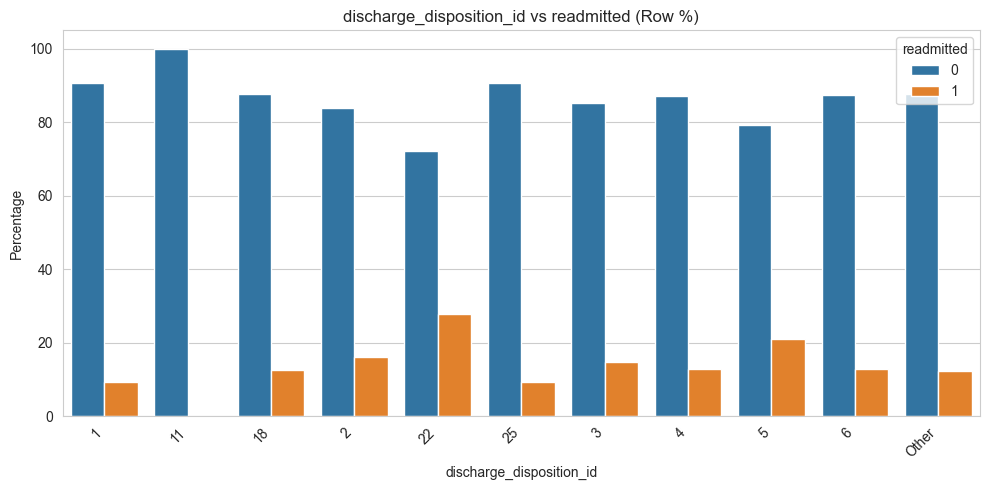

### admission_source_id

**Count Table**

readmitted,0,1
admission_source_id,,
1,26435,3130
17,6075,706
2,993,111
20,139,22
3,158,29
4,2878,309
5,754,101
6,2052,212
7,50774,6720


**Row Percentage Table**

readmitted,0,1
admission_source_id,,
1,89.41,10.59
17,89.59,10.41
2,89.95,10.05
20,86.34,13.66
3,84.49,15.51
4,90.30,9.70
5,88.19,11.81
6,90.64,9.36
7,88.31,11.69


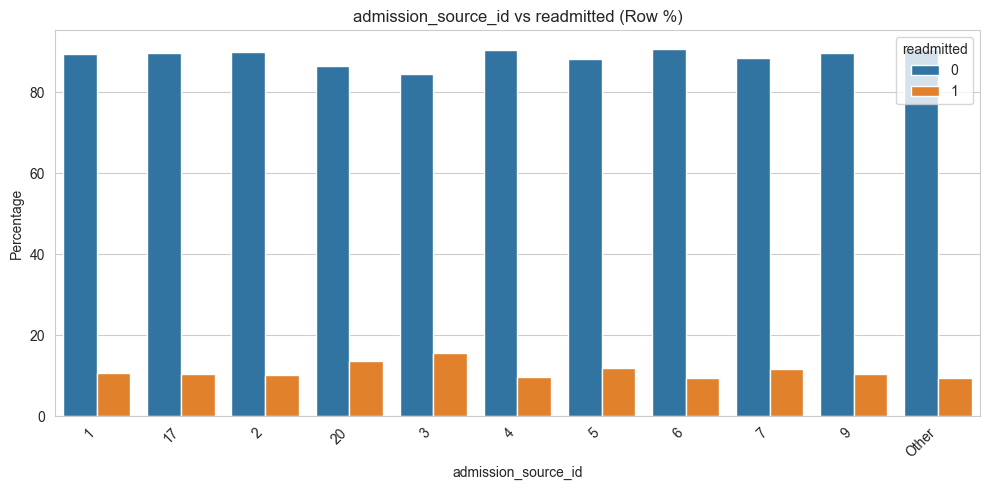

### medical_specialty

**Count Table**

readmitted,0,1
medical_specialty,,
Cardiology,4927,425
Emergency/Trauma,6719,846
Family/GeneralPractice,6557,883
InternalMedicine,12989,1646
Nephrology,1365,248
Orthopedics,1249,151
Orthopedics-Reconstructive,1141,92
Other,7500,840
Radiologist,1037,103


**Row Percentage Table**

readmitted,0,1
medical_specialty,,
Cardiology,92.06,7.94
Emergency/Trauma,88.82,11.18
Family/GeneralPractice,88.13,11.87
InternalMedicine,88.75,11.25
Nephrology,84.62,15.38
Orthopedics,89.21,10.79
Orthopedics-Reconstructive,92.54,7.46
Other,89.93,10.07
Radiologist,90.96,9.04


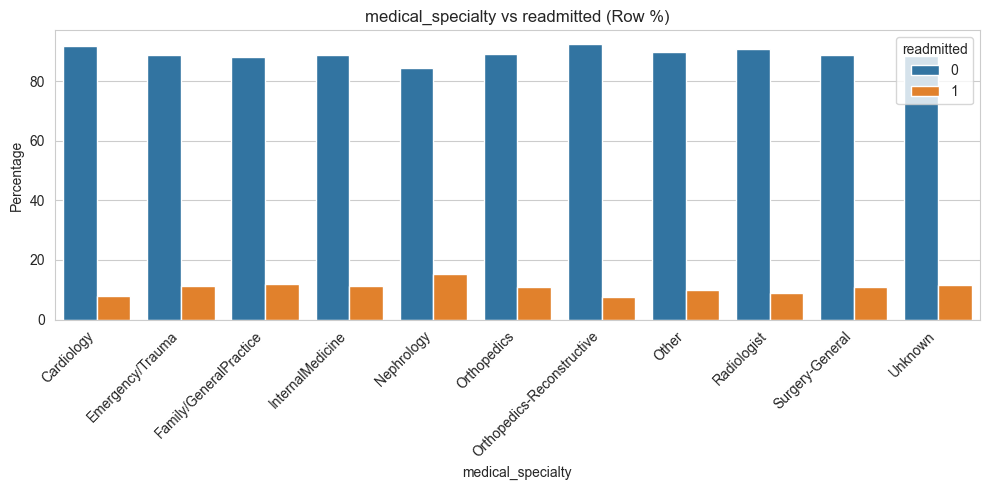

### max_glu_serum

**Count Table**

readmitted,0,1
max_glu_serum,,
>200,1300,185
>300,1083,181
Norm,2302,295
none,85724,10696


**Row Percentage Table**

readmitted,0,1
max_glu_serum,,
>200,87.54,12.46
>300,85.68,14.32
Norm,88.64,11.36
none,88.91,11.09


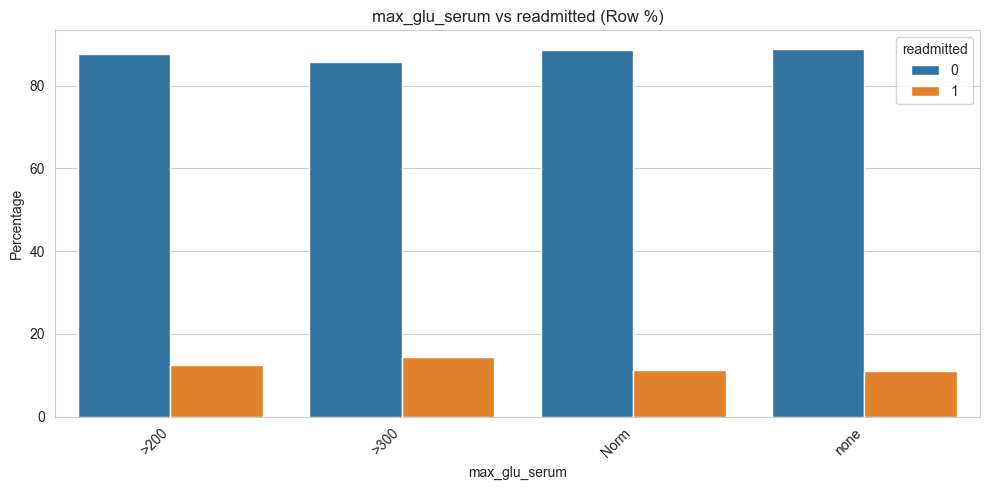

### A1Cresult

**Count Table**

readmitted,0,1
A1Cresult,,
>7,3429,383
>8,7405,811
Norm,4508,482
none,75067,9681


**Row Percentage Table**

readmitted,0,1
A1Cresult,,
>7,89.95,10.05
>8,90.13,9.87
Norm,90.34,9.66
none,88.58,11.42


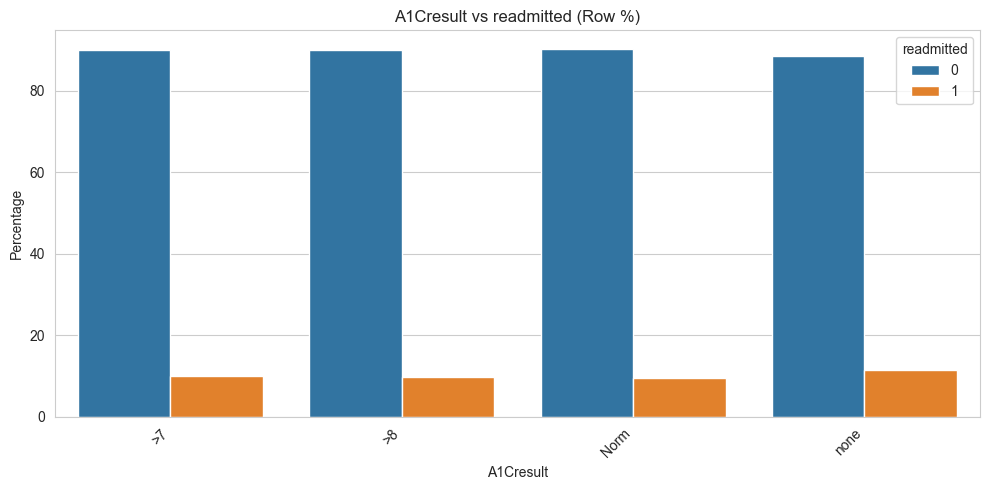

### change

**Count Table**

readmitted,0,1
change,,
Ch,41453,5558
No,48956,5799


**Row Percentage Table**

readmitted,0,1
change,,
Ch,88.18,11.82
No,89.41,10.59


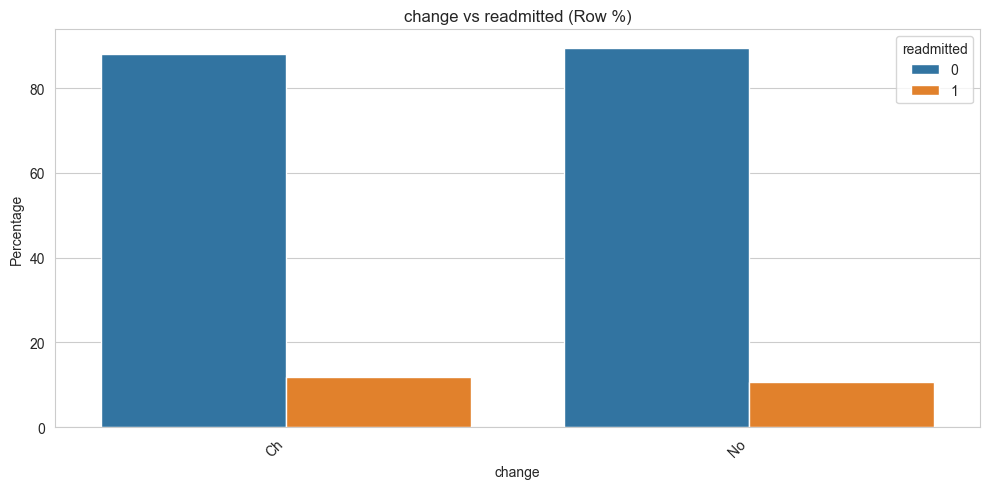

### diabetesMed

**Count Table**

readmitted,0,1
diabetesMed,,
No,21157,2246
Yes,69252,9111


**Row Percentage Table**

readmitted,0,1
diabetesMed,,
No,90.40,9.60
Yes,88.37,11.63


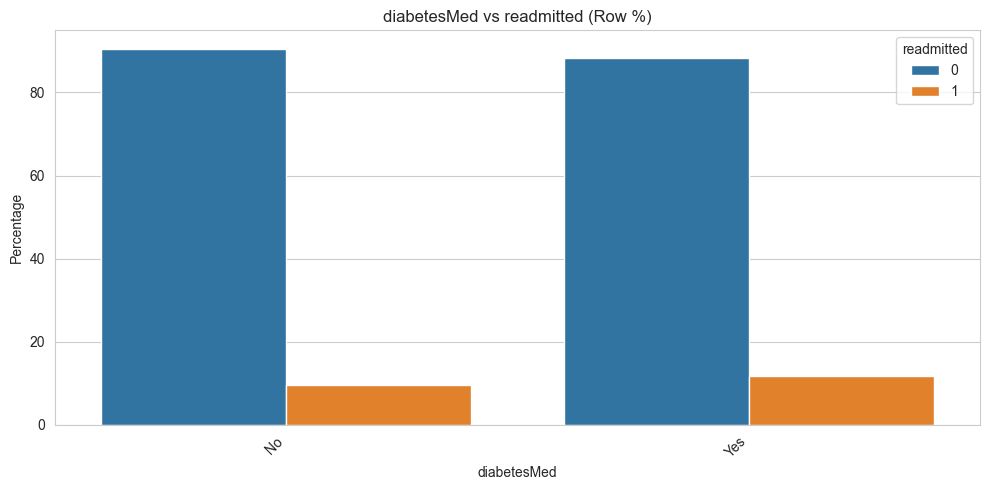

### insulin

**Count Table**

readmitted,0,1
insulin,,
Down,10520,1698
No,42627,4756
Steady,27416,3433
Up,9846,1470


**Row Percentage Table**

readmitted,0,1
insulin,,
Down,86.10,13.90
No,89.96,10.04
Steady,88.87,11.13
Up,87.01,12.99


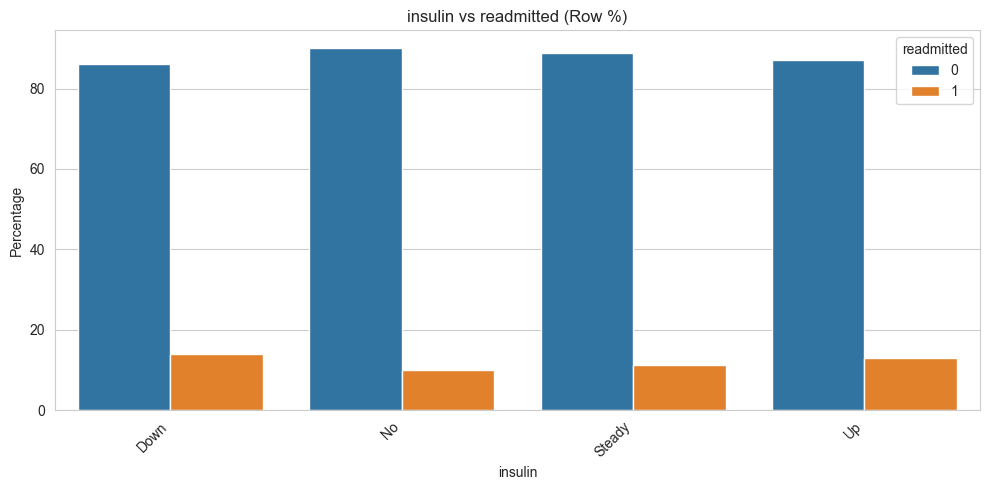

In [19]:
categorical_bivariate_columns = ['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'medical_specialty', 'max_glu_serum', 'A1Cresult', 'change', 'diabetesMed', 'insulin']
display_bivariate_analysis(df_cleaned, target, None, categorical_bivariate_columns)

Across the 12 categorical features, the bivariate analysis reveals a wide range of discriminative power — from features that are essentially flat against the target to one that exposes a clear leakage risk and others with clinically meaningful, actionable readmission rate differences.

**Race and gender carry negligible predictive signal.** Readmission rates across all racial groups span only from 8.27% (`Unknown`) to 11.29% (`Caucasian`), a range of roughly 3 percentage points with no group meaningfully above the population mean of 11.2%. Male (11.06%) and female (11.25%) patients are effectively identical. Neither feature justifies inclusion in the model on predictive grounds alone. They remain mandatory inclusions for fairness evaluation — the Caucasian-dominated training distribution requires explicit assessment of differential model performance across racial subgroups — but should not be expected to contribute to predictive power.

**Age exhibits a non-monotonic readmission gradient.** Counterintuitively, the [20–30) cohort has the highest readmission rate in the dataset (14.24%), followed by the [80–90) and [70–80) cohorts (12.08% and 11.77%). Middle-aged groups ([40–50), [50–60)) sit below the population mean, while the youngest buckets ([0–10), [10–20)) are far below at 1.86% and 5.79%. The elevated rate in the 20–30 cohort likely reflects a small but severely ill subgroup — younger patients with poorly controlled or insulin-dependent diabetes and early-onset complications — rather than a general youth-readmission pattern. The non-monotonic shape means that naive ordinal encoding or simple age midpoints will not capture the full signal; the most defensible approach is either one-hot encoding of the age bands or a mapping that allows the 20–30 cohort to be treated as a distinct risk segment rather than the lowest-risk end of a linear scale.

**Admission type is a weak differentiator.** Emergency admissions (code 1) produce the highest readmission rate (11.52%), followed closely by urgent (11.18%) and elective (10.39%). The maximum spread across main categories barely exceeds 1 percentage point. While the direction aligns with clinical intuition — emergency admissions represent unplanned, higher-acuity presentations — the narrow range suggests this feature will contribute little standalone predictive power.

**Discharge disposition is the strongest administrative predictor and contains a confirmed leakage risk.** Code 11 (Expired during encounter, n=1,642) shows 0% readmission — not because discharge type reduces risk, but because these patients are structurally incapable of readmission. This must be filtered out before training; the structural zero confirms the leakage concern raised at the univariate stage, and retaining these records would introduce a trivially correct negative signal that does not generalise. Several hospice and undefined codes (17, 19, 20, 27) similarly produce 0% and should be handled the same way. Among clinically valid codes, the spread is substantial: rehab facility transfers (code 22, 27.70%) and SNF transfers (code 3, 14.66%) sit far above home discharges (code 1, 9.30%), which are actually below the population mean. This pattern reflects patient complexity — those transferred to skilled facilities are higher-acuity cases with ongoing care needs, while patients discharged directly home are to some extent selected for stability. For modeling, grouping discharge codes into clinically coherent buckets — home, facility/SNF transfer, inpatient transfer, expired/hospice — would retain the signal while managing the extreme cardinality.

**Admission source shows meaningful signal from transfer codes, but the dominant volume is flat.** The two highest-volume codes — Emergency Room (code 7, n=57,494) at 11.69% and physician referral (code 1, n=29,565) at 10.59% — are both close to the population mean and differ by only 1.1 percentage points. However, hospital transfer (code 3, n=187) at 15.51% and code 20 (n=161) at 13.66% show notably elevated readmission rates. Code 3 in ICD-9 admission source mapping corresponds to transfer from another hospital — a high-acuity patient pathway where the original facility lacked the capacity to manage the case — and a 15.51% readmission rate is clinically plausible for that subgroup. These transfer codes have modest sample sizes and will have limited influence on model training in their raw form, but they do represent a genuine signal. The recommended grouping — ER, physician/clinic referral, hospital transfer, and other — would preserve this transfer signal as a distinct category rather than folding it into a residual bucket.

**Medical specialty reveals clinically interpretable but modest differentiation.** Nephrology produces the highest readmission rate among visible specialties (15.38%, n=1,613) — consistent with chronic kidney disease being a leading driver of readmission in the diabetic population. At the other end, Cardiology (7.94%, n=5,352) and Orthopedics-Reconstructive (7.46%, n=1,233) sit well below the mean. Cardiology's low rate may reflect intensive post-discharge protocols and the elective nature of many cardiac procedures; orthopaedic cases are consistent with the surgical mechanism noted for `num_procedures`. The `Unknown` specialty group (n=49,949) is close to the population mean at 11.57%, confirming it carries no directional signal on its own; deriving a `specialty_known` binary indicator alongside the grouped specialty label remains the recommended approach.

**Glucose serum levels show a modest but directionally correct signal.** Among tested patients, `>300` carries a 14.32% readmission rate, compared to 12.46% for `>200`, 11.36% for `Normal`, and 11.09% for the untested `none` majority. The gradient is in the expected direction — more severe acute hyperglycaemia correlates with higher readmission — and the `>300` group sits roughly 3.2 percentage points above the untested population. Given that 94.7% of records are `none`, the raw feature has limited overall discriminative power, but a binary `glucose_tested` flag paired with the measured level (as a separate ordinal feature) would preserve the meaningful signal from the tested subgroup.

**HbA1c result produces an inverted and counterintuitive pattern.** The untested group (`none`, n=84,748) has the highest readmission rate at 11.42%, while the tested groups range from 9.66% (`Normal`) to 10.05% (`>7`), all below the mean. Critically, the `>8` group (poorly controlled, n=8,216) is not elevated at 9.87%. This inversion most likely reflects a selection effect: HbA1c testing is typically ordered for patients under active glycaemic management review, meaning the tested population has received closer clinical attention that influences outcomes independently of control level. The practical implication is that the feature's raw categories cannot be treated as a simple risk scale. The most reliable representation is a binary `A1C_tested` flag; the ordinal level should be included as a secondary feature, but its directional contribution should be interpreted cautiously.

**Medication change and diabetes medication prescription show small but consistent signals.** Encounters with a medication change (`Ch`) have an 11.82% readmission rate versus 10.59% for unchanged cases — a 1.2 percentage-point difference directionally consistent with change reflecting clinical instability. Patients on any diabetes medication (`Yes`, 11.63%) have a higher readmission rate than those without (`No`, 9.60%), a pattern better explained by disease severity confounding — patients not on medication may have milder or newly diagnosed disease — than by medication causing readmission. Both effects are modest but consistent.

**Insulin dose trajectory is the strongest treatment-status predictor.** The four categories produce a clear and clinically meaningful gradient: `Down` (13.90%) > `Up` (12.99%) > `Steady` (11.13%) > `No` (10.04%). Both active adjustments are 3–4 percentage points above the no-insulin baseline, with dose reduction marginally exceeding dose increase in readmission rate. This supports the hypothesis that any dose titration — regardless of direction — signals glycaemic instability that elevates readmission risk. The binary `insulin_adjusted` flag is well supported by these rates. More granularly, retaining all four levels in an ordinal or nominal encoding would allow the model to distinguish stable from unstable regimens, which is the most informative split this feature offers.

### Correlation Analysis

This section reviews both feature-to-target and feature-to-feature correlations among numerical variables. The goal is to identify potentially informative features, detect redundancy, and support preprocessing decisions before modeling.

### Numerical Feature Correlation with Target

**Feature-to-Target Correlation Table**

,readmitted
number_inpatient,0.165
number_emergency,0.061
number_diagnoses,0.050
time_in_hospital,0.044
num_medications,0.038
num_lab_procedures,0.020
number_outpatient,0.019
num_procedures,-0.012


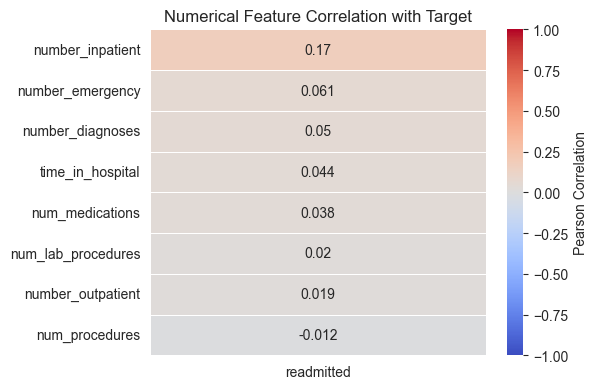

**Interpretation Guide**

- Positive values indicate that higher feature values tend to be associated with the positive target class.
- Negative values indicate an inverse relationship with the target.
- Correlations close to zero suggest weak linear association, though such features may still be useful in nonlinear or interaction-based models.

**Top Positive Correlations with Target**

,readmitted
number_inpatient,0.165
number_emergency,0.061
number_diagnoses,0.050


**Top Negative Correlations with Target**

,readmitted
num_procedures,-0.012


### Numerical Feature Correlation Analysis

**Correlation Matrix**

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
time_in_hospital,1.000,0.318,0.191,0.466,-0.009,-0.010,0.074,0.220
num_lab_procedures,0.318,1.000,0.058,0.268,-0.008,-0.002,0.039,0.153
num_procedures,0.191,0.058,1.000,0.386,-0.025,-0.038,-0.066,0.074
num_medications,0.466,0.268,0.386,1.000,0.045,0.013,0.064,0.262
number_outpatient,-0.009,-0.008,-0.025,0.045,1.000,0.091,0.107,0.094
number_emergency,-0.010,-0.002,-0.038,0.013,0.091,1.000,0.267,0.056
number_inpatient,0.074,0.039,-0.066,0.064,0.107,0.267,1.000,0.105
number_diagnoses,0.220,0.153,0.074,0.262,0.094,0.056,0.105,1.000


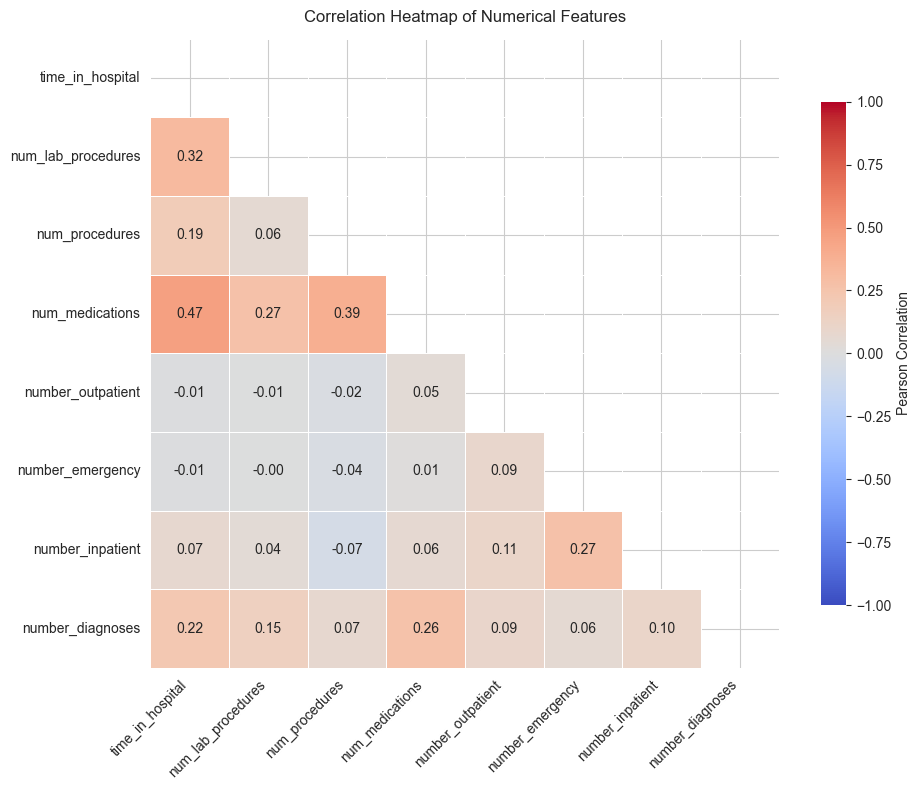

**Top 10 Strongest Pairwise Correlations**

,feature_1,feature_2,correlation,abs_correlation
0,time_in_hospital,num_medications,0.466,0.466
1,num_procedures,num_medications,0.386,0.386
2,time_in_hospital,num_lab_procedures,0.318,0.318
3,num_lab_procedures,num_medications,0.268,0.268
4,number_emergency,number_inpatient,0.267,0.267
5,num_medications,number_diagnoses,0.262,0.262
6,time_in_hospital,number_diagnoses,0.220,0.220
7,time_in_hospital,num_procedures,0.191,0.191
8,num_lab_procedures,number_diagnoses,0.153,0.153
9,number_outpatient,number_inpatient,0.107,0.107


### Interpretation Notes

- **Feature-to-feature correlation** helps identify potentially redundant variables and possible multicollinearity concerns, especially for linear models.
- **Feature-to-target correlation** is useful for screening direct linear signal, but it should not be treated as a final measure of feature importance.
- Tree-based models can still benefit from features with weak target correlation if those features contribute through nonlinear splits or interactions.
- If very strong pairwise correlations are found, consider whether both features should be retained, transformed, regularized, or reviewed for redundancy.

In [50]:
def display_correlation_analysis(
    dataframe,
    numerical_cols,
    target_col=None,
    method="pearson",
    top_n_pairs=10,
    feature_figsize=(10, 8),
    target_figsize=(6, 4)
):
    """
    Display notebook-friendly correlation analysis for numerical features,
    including feature-to-target and feature-to-feature relationships.

    This helper is intended for exploratory data analysis inside a notebook.
    It presents correlation outputs in a way that is useful for preprocessing,
    feature selection, redundancy checks, and interpretation before modeling.

    If a target column is provided and is numeric (for example, a binary target
    encoded as 0 and 1), the function also computes and visualizes correlation
    between each numerical feature and the target.

    Parameters:
    -----------
    dataframe : pd.DataFrame
        Input dataframe containing the numerical features and optional target.

    numerical_cols : list of str
        Numerical columns to include in the correlation analysis.

    target_col : str, optional
        Target variable column name. If provided, the function computes feature-
        to-target correlation in addition to feature-to-feature correlation.

    method : str, default='pearson'
        Correlation method to use. Common choices are:
        - 'pearson' for linear correlation
        - 'spearman' for monotonic/rank-based correlation

    top_n_pairs : int, default=10
        Number of strongest feature-to-feature correlation pairs to display.

    feature_figsize : tuple, default=(10, 8)
        Figure size for the numerical feature correlation heatmap.

    target_figsize : tuple, default=(6, 4)
        Figure size for the feature-to-target correlation heatmap.

    Returns:
    --------
    None
        This function is intended for notebook display and reporting rather than
        returning analysis objects.

    Notes:
    ------
    - Feature-to-feature correlation is mainly used to detect redundancy and
      possible multicollinearity among numerical predictors.
    - Feature-to-target correlation is useful for identifying direct linear
      association, but low correlation does not imply a feature is unimportant.
      Some variables may still be useful through nonlinear effects or interactions.
    - In binary classification, Pearson correlation with a 0/1 target is valid
      as a quick screening tool, but it should not be treated as a final feature
      selection criterion.
    """

    # ----------------------------------------
    # Validation
    # ----------------------------------------
    if numerical_columns is None or len(numerical_cols) == 0:
        raise ValueError("numerical_cols must contain at least one numerical column.")

    missing_cols = [col for col in numerical_cols if col not in dataframe.columns]
    if missing_cols:
        raise ValueError(f"These numerical columns are missing from the dataframe: {missing_cols}")

    if target_col is not None and target_col not in dataframe.columns:
        raise ValueError(f"Target column '{target_col}' not found in dataframe.")

    # ----------------------------------------
    # Part 1: Correlation with Target
    # ----------------------------------------
    if target_col is not None:
        display(Markdown("### Numerical Feature Correlation with Target"))

        target_corr = (
            dataframe[list(numerical_cols) + [target_col]]
            .corr(method=method)[[target_col]]
            .drop(index=target_col)
            .sort_values(by=target_col, ascending=False)
        )

        display(Markdown("**Feature-to-Target Correlation Table**"))
        display(target_corr.round(3))

        plt.figure(figsize=target_figsize)
        sns.heatmap(
            target_corr,
            annot=True,
            cmap="coolwarm",
            center=0,
            vmin=-1,
            vmax=1,
            linewidths=0.5,
            cbar_kws={"label": f"{method.title()} Correlation"}
        )
        plt.title("Numerical Feature Correlation with Target")
        plt.tight_layout()
        plt.show()

        top_positive = target_corr[target_corr[target_col] > 0].head(3)
        top_negative = target_corr[target_corr[target_col] < 0].head(3)

        display(Markdown("**Interpretation Guide**"))
        display(Markdown(
            "- Positive values indicate that higher feature values tend to be associated "
            "with the positive target class.\n"
            "- Negative values indicate an inverse relationship with the target.\n"
            "- Correlations close to zero suggest weak linear association, though such "
            "features may still be useful in nonlinear or interaction-based models."
        ))

        if not top_positive.empty:
            display(Markdown("**Top Positive Correlations with Target**"))
            display(top_positive.round(3))

        if not top_negative.empty:
            display(Markdown("**Top Negative Correlations with Target**"))
            display(top_negative.round(3))

    # ----------------------------------------
    # Part 2: Feature-to-Feature Correlation
    # ----------------------------------------
    display(Markdown("### Numerical Feature Correlation Analysis"))

    corr_matrix = dataframe[numerical_cols].corr(method=method)

    display(Markdown("**Correlation Matrix**"))
    display(corr_matrix.round(3))

    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

    plt.figure(figsize=feature_figsize)
    sns.heatmap(
        corr_matrix,
        mask=mask,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        vmin=-1,
        vmax=1,
        linewidths=0.5,
        square=True,
        cbar_kws={"shrink": 0.8, "label": f"{method.title()} Correlation"}
    )
    plt.title("Correlation Heatmap of Numerical Features", pad=12)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # ----------------------------------------
    # Part 3: Strongest Pairwise Correlations
    # ----------------------------------------
    corr_pairs = (
        corr_matrix.where(~np.eye(corr_matrix.shape[0], dtype=bool))
        .stack()
        .reset_index()
    )
    corr_pairs.columns = ["feature_1", "feature_2", "correlation"]

    corr_pairs["pair_key"] = corr_pairs.apply(
        lambda row: tuple(sorted([row["feature_1"], row["feature_2"]])),
        axis=1
    )
    corr_pairs = corr_pairs.drop_duplicates(subset="pair_key").drop(columns="pair_key")

    corr_pairs["abs_correlation"] = corr_pairs["correlation"].abs()
    corr_pairs = corr_pairs.sort_values("abs_correlation", ascending=False)

    display(Markdown(f"**Top {top_n_pairs} Strongest Pairwise Correlations**"))
    display(corr_pairs.head(top_n_pairs).reset_index(drop=True).round(3))

    # ----------------------------------------
    # Part 4: Interpretation Notes
    # ----------------------------------------
    display(Markdown("### Interpretation Notes"))
    display(Markdown(
        "- **Feature-to-feature correlation** helps identify potentially redundant "
        "variables and possible multicollinearity concerns, especially for linear models.\n"
        "- **Feature-to-target correlation** is useful for screening direct linear "
        "signal, but it should not be treated as a final measure of feature importance.\n"
        "- Tree-based models can still benefit from features with weak target correlation "
        "if those features contribute through nonlinear splits or interactions.\n"
        "- If very strong pairwise correlations are found, consider whether both features "
        "should be retained, transformed, regularized, or reviewed for redundancy."
    ))

display_correlation_analysis(df_cleaned, numerical_columns, target)

The Pearson correlation heatmap and pairwise ranking table reveal a set of modest but interpretable inter-feature relationships among the eight numerical columns, with uniformly weak correlations against the binary target.

**Modeling implications.** The weak linear target correlations reinforce that this is a non-linear classification problem where interaction effects and ensemble methods (Random Forest, XGBoost) are expected to outperform linear baselines. For any linear model included in the comparison, the `time_in_hospital`–`num_medications` correlation (r = 0.466) and the broader encounter-intensity cluster should be assessed via VIF; log1p transformations of the zero-inflated prior utilisation variables will also help stabilise correlation estimates. No pair exceeds the 0.7–0.8 threshold typically associated with problematic multicollinearity, so no feature needs to be removed on correlation grounds alone.

**Target correlations are weak across the board.** The strongest individual correlations with `readmitted` are `number_inpatient` (r = 0.165), `number_emergency` (r = 0.061), and `number_diagnoses` (r = 0.050). All remaining features — `time_in_hospital`, `num_medications`, `num_lab_procedures`, `number_outpatient`, and `num_procedures` — produce target correlations below 0.05 in absolute value. This is consistent with the bivariate analysis, which showed that `number_inpatient` and `number_emergency` carried the largest mean-based separation. The low linear correlations for the other six features do not imply they are uninformative — Pearson correlation measures only linear association and is sensitive to the extreme zero-inflation and right skew present in these distributions. Tree-based models will likely extract non-linear signal that this metric cannot capture.

**Prior utilisation features are largely independent of the encounter-intensity cluster.** `number_inpatient` and `number_emergency` correlate most strongly with each other (r = 0.267), reflecting that patients with high emergency visit history also tend to have more inpatient admissions. Their correlations with the encounter-intensity features are all below 0.11, confirming that prior utilisation is capturing a distinct dimension of patient risk from what the current-encounter variables measure. This independence strengthens the case for retaining all three prior utilisation variables alongside the current-encounter features — they are not redundant with each other.

**The strongest feature–feature correlation is between `time_in_hospital` and `num_medications` (r = 0.466).** This is the only pair approaching moderate correlation in the dataset. Clinically, the relationship is intuitive: longer stays tend to accompany more complex pharmacotherapy. For linear models, this degree of correlation is worth monitoring — a VIF check at the modeling stage is warranted — but it is not high enough to mandate dropping either feature outright. For tree-based models, this collinearity is harmless.

**`num_medications` and `number_diagnoses` also correlate with each other (r = 0.262) and with `num_lab_procedures` (r = 0.268).** These pairings reinforce the encounter-intensity cluster and are all clinically coherent — more diagnoses imply more medications and more diagnostic workup. None of these pairwise values crosses 0.5, so multicollinearity remains a moderate rather than critical concern.

**A cluster of encounter-intensity correlations forms around `time_in_hospital`.** Beyond its correlation with `num_medications`, `time_in_hospital` also correlates moderately with `num_lab_procedures` (r = 0.318), `num_procedures` (r = 0.191), and `number_diagnoses` (r = 0.220). Together, these four features describe the complexity and resource intensity of the index encounter and move together to some degree — patients with longer stays tend to receive more procedures, more lab work, more medications, and carry more diagnoses. This cluster does not indicate redundancy severe enough to require feature removal, but it does suggest that any dimensionality reduction (e.g., PCA) applied to linear models could effectively compress these four into a single "encounter intensity" component without major information loss.

### EDA for Preprocessing

This section consolidates the completed EDA into concrete preprocessing decisions for modeling.

### Final Preprocessing Decisions

**1) Leakage and invalid-target records**
- Exclude `discharge_disposition_id == 11` (Expired) before training; these encounters are structurally non-readmittable and create leakage.
- Group hospice/structural-zero discharge codes (e.g., 17/19/20/27) into an exclusion or controlled bucket consistent with modeling scope.

**2) Missingness handling**
- Keep `max_glu_serum` and `A1Cresult` with `'none'` retained as informative missingness.
- Keep `race` with `'Unknown'` for fairness monitoring.
- Keep grouped `medical_specialty` and add `specialty_known` (1 if not `Unknown`, else 0).

**3) Numerical transformations**
- Apply `log1p` to zero-inflated utilization features: `number_outpatient`, `number_emergency`, `number_inpatient` (and optionally `num_medications` for linear baselines).
- Add binary utilization flags: `had_outpatient`, `had_emergency`, `had_inpatient`.
- Add `had_procedures` from `num_procedures` (limited standalone signal).

**4) Categorical engineering**
- `age`: use one-hot bands (preferred) or a non-linear ordinal mapping preserving the elevated [20–30) risk segment.
- `discharge_disposition_id`: collapse to clinically coherent groups (home, SNF/rehab/facility transfer, inpatient transfer, excluded structural-zero).
- `admission_source_id`: collapse into ER, physician/clinic referral, hospital transfer, other.
- `insulin`: retain 4-level category and add `insulin_adjusted` (`Down`/`Up` vs `Steady`/`No`).
- `change` and `diabetesMed`: keep as binary indicators.
- `max_glu_serum` and `A1Cresult`: include tested flags (`glucose_tested`, `A1C_tested`) plus level categories.

**5) Correlation and redundancy**
- Keep all numerical features; no pair exceeds severe multicollinearity thresholds.
- Monitor VIF for linear models, especially the encounter-intensity cluster (`time_in_hospital`, `num_medications`, `num_lab_procedures`, `number_diagnoses`).

**6) Modeling readiness**
- Use stratified split with `RANDOM_STATE = 42`.
- Address class imbalance via class weights and/or SMOTE during training.
- Prioritize tree-based models for non-linear effects; keep linear baselines with transformed/scaled inputs for comparison.
- Reserve `race` and `gender` for fairness auditing even if predictive contribution is weak.

### Final Preprocessing

This section implements the pipeline decisions derived from EDA. Each step is wrapped in a helper function for clarity and reusability. The output is `df_preprocessed`, which will be the input to the feature engineering section.

In [51]:
def filter_leakage_records(dataframe: pd.DataFrame) -> pd.DataFrame:
    """
    Remove records that are structurally incapable of 30-day readmission.

    Encounters where discharge_disposition_id == 11 (Expired/Died During Encounter)
    cannot be readmitted. Retaining them introduces label leakage because the model
    would trivially learn to predict 'not readmitted' for all expired rows, inflating
    apparent performance without learning any clinically useful signal.

    Parameters
    ----------
    dataframe : pd.DataFrame
        Cleaned DataFrame output from the data-cleaning pipeline.

    Returns
    -------
    pd.DataFrame
        DataFrame with expired encounters removed (a copy, not an in-place edit).
    """
    n_before = len(dataframe)
    df_filtered = dataframe[dataframe['discharge_disposition_id'] != 11].copy()
    n_removed = n_before - len(df_filtered)
    print(f"✓ Removed {n_removed:,} expired encounters (discharge_disposition_id == 11)")
    print(f"  Records remaining: {len(df_filtered):,}")
    return df_filtered


df_preprocessed = filter_leakage_records(df_cleaned)
print("✓ df_preprocessed created from df_cleaned")

✓ Removed 1,642 expired encounters (discharge_disposition_id == 11)
  Records remaining: 100,124
✓ df_preprocessed created from df_cleaned


In [52]:
def add_utilization_features(dataframe: pd.DataFrame) -> pd.DataFrame:
    """
    Engineer binary flags and log1p transforms for the zero-inflated utilization columns.

    All three prior-utilization variables (number_outpatient, number_emergency,
    number_inpatient) are heavily zero-inflated with long right tails. This function
    addresses both issues simultaneously:

    Binary flags ('had_outpatient', 'had_emergency', 'had_inpatient', 'had_procedures')
        Capture any-vs-none variation cleanly. For highly zero-inflated columns the
        binary flag often carries as much discriminative signal as the raw count and is
        robust to extreme values.

    Log1p transforms ('log_outpatient', 'log_emergency', 'log_inpatient')
        Compress the right tail for linear and distance-based models. log1p(x) = log(1+x)
        is safe for zero values (log1p(0) = 0) while substantially reducing skewness.

    The original count columns are retained so that tree-based models (Random Forest,
    XGBoost) can partition on raw values without any information loss.

    Parameters
    ----------
    dataframe : pd.DataFrame
        DataFrame after leakage filtering.

    Returns
    -------
    pd.DataFrame
        DataFrame with utilization flags and log1p transforms added as new columns.
    """
    df_out = dataframe.copy()

    util_cols  = ['number_outpatient', 'number_emergency', 'number_inpatient']
    flag_names = ['had_outpatient',    'had_emergency',    'had_inpatient']
    log_names  = ['log_outpatient',    'log_emergency',    'log_inpatient']

    for raw, flag, log in zip(util_cols, flag_names, log_names):
        df_out[flag] = (df_out[raw] > 0).astype(int)
        df_out[log]  = np.log1p(df_out[raw])

    df_out['had_procedures'] = (df_out['num_procedures'] > 0).astype(int)

    print("✓ Binary utilization flags added:", flag_names + ['had_procedures'])
    print("✓ Log1p transforms added:", log_names)
    return df_out


df_preprocessed = add_utilization_features(df_preprocessed)

✓ Binary utilization flags added: ['had_outpatient', 'had_emergency', 'had_inpatient', 'had_procedures']
✓ Log1p transforms added: ['log_outpatient', 'log_emergency', 'log_inpatient']


In [53]:
def group_discharge_disposition(dataframe: pd.DataFrame) -> pd.DataFrame:
    """
    Collapse discharge_disposition_id into four clinically coherent string groups.

    The 25+ distinct numeric codes are replaced with interpretable labels that
    reflect the patient's post-discharge care trajectory:

        'home'      Discharged to home (with or without home-health support).
                    Raw codes: 1, 6, 8
                    Baseline group; lowest mean readmission rate (~9.3%).

        'facility'  Transferred to a post-acute or long-term care facility
                    (SNF, ICF, rehab unit, long-term hospital, federal facility,
                    psychiatric hospital, CAH, etc.).
                    Raw codes: 2, 3, 4, 5, 10, 15, 22, 23, 24, 25, 26, 27, 28, 29, 30
                    Elevated readmission risk; includes the highest-risk SNF/rehab codes.

        'inpatient' Still in care or expected to return for inpatient services.
                    Raw codes: 9, 12

        'other'     AMA (left against medical advice), hospice discharge, outpatient
                    referrals, unknown, unmapped, and any remaining codes not assigned
                    to the three groups above.

    Note: discharge_disposition_id == 11 (Expired) is excluded upstream by
    filter_leakage_records(), so it will not appear here.

    The original numeric column is replaced in-place with the string labels.
    One-hot encoding is deferred to the feature-engineering step.

    Parameters
    ----------
    dataframe : pd.DataFrame
        DataFrame after utilization feature engineering.

    Returns
    -------
    pd.DataFrame
        DataFrame with discharge_disposition_id replaced by string group labels.
    """
    df_out = dataframe.copy()

    discharge_map = {
        1: 'home', 6: 'home', 8: 'home',
        2: 'facility', 3: 'facility',  4: 'facility',  5: 'facility',
        10: 'facility', 15: 'facility', 22: 'facility', 23: 'facility',
        24: 'facility', 25: 'facility', 26: 'facility', 27: 'facility',
        28: 'facility', 29: 'facility', 30: 'facility',
        9: 'inpatient', 12: 'inpatient',
    }

    df_out['discharge_disposition_id'] = (
        df_out['discharge_disposition_id']
        .map(discharge_map)
        .fillna('other')
    )

    print("✓ discharge_disposition_id grouped into clinical categories:")
    print(df_out['discharge_disposition_id'].value_counts().to_string())
    return df_out


df_preprocessed = group_discharge_disposition(df_preprocessed)

✓ discharge_disposition_id grouped into clinical categories:
discharge_disposition_id
home         73244
facility     21736
other         5120
inpatient       24


In [54]:
def group_admission_source(dataframe: pd.DataFrame) -> pd.DataFrame:
    """
    Collapse admission_source_id into four clinically interpretable string groups.

    The coded numeric values are mapped to interpretable labels that capture the
    clinical meaning of how a patient arrived at the hospital:

        'emergency_room'  Arrived directly via the emergency department.
                          Raw codes: 7
                          Highest-volume group; likely higher acuity on arrival.

        'referral'        Admitted via a physician or clinic referral, representing
                          a planned or semi-planned admission.
                          Raw codes: 1, 2

        'transfer'        Transferred from another healthcare facility (hospital, SNF,
                          HMO, ambulatory surgery center, hospice, or other care setting).
                          Raw codes: 3, 4, 5, 6, 10, 18, 22, 25, 26
                          Bivariate analysis showed HMO referral (code 3, 15.51%) and
                          transfer codes carried elevated readmission rates, motivating
                          a dedicated group rather than folding into 'other'.

        'other'           Court/Law Enforcement, not-available, null, unknown,
                          and any remaining codes not assigned above.

    The original numeric column is replaced with the string labels.
    One-hot encoding is deferred to the feature-engineering step.

    Parameters
    ----------
    dataframe : pd.DataFrame
        DataFrame after discharge disposition grouping.

    Returns
    -------
    pd.DataFrame
        DataFrame with admission_source_id replaced by string group labels.
    """
    df_out = dataframe.copy()

    admission_map = {
        7:  'emergency_room',
        1:  'referral', 2: 'referral',
        3:  'transfer', 4: 'transfer', 5:  'transfer', 6: 'transfer',
        10: 'transfer', 18: 'transfer', 22: 'transfer', 25: 'transfer', 26: 'transfer',
    }

    df_out['admission_source_id'] = (
        df_out['admission_source_id']
        .map(admission_map)
        .fillna('other')
    )

    print("✓ admission_source_id grouped into clinical categories:")
    print(df_out['admission_source_id'].value_counts().to_string())
    return df_out


df_preprocessed = group_admission_source(df_preprocessed)

✓ admission_source_id grouped into clinical categories:
admission_source_id
emergency_room    56370
referral          30407
other              6950
transfer           6397


In [55]:
def encode_clinical_flags(dataframe: pd.DataFrame) -> pd.DataFrame:
    """
    Add binary indicator flags from categorical clinical variables and recode
    change/diabetesMed to 0/1 integers.

    New columns created:

        specialty_known   1 if medical_specialty is not 'Unknown', else 0.
                          Separates the informative specialty signal from pure
                          missingness; allows models to use both dimensions of
                          this feature without conflating them.

        insulin_adjusted  1 if insulin was actively changed during admission
                          ('Down' or 'Up'), else 0. Captures whether the
                          treating physician adjusted dosage — a signal of
                          suboptimal glycaemic control on entry.

        glucose_tested    1 if max_glu_serum is not 'none', else 0.
                          Whether an inpatient glucose test was ordered is a
                          clinical decision that may independently distinguish
                          high-acuity from routine admissions.

        A1C_tested        1 if A1Cresult is not 'none', else 0.
                          Analogous reasoning to glucose_tested.

    Columns recoded in-place:

        change      'Ch' → 1 (medication change occurred), 'No' → 0.
        diabetesMed 'Yes' → 1 (diabetes medication prescribed), 'No' → 0.

    The original insulin, max_glu_serum, and A1Cresult columns are retained
    with their level categories for use in feature engineering.

    Parameters
    ----------
    dataframe : pd.DataFrame
        DataFrame after admission source grouping.

    Returns
    -------
    pd.DataFrame
        DataFrame with the four indicator columns added and change/diabetesMed recoded.
    """
    df_out = dataframe.copy()

    df_out['specialty_known']  = (df_out['medical_specialty'] != 'Unknown').astype(int)
    df_out['insulin_adjusted'] = df_out['insulin'].isin(['Down', 'Up']).astype(int)
    df_out['glucose_tested']   = (df_out['max_glu_serum'] != 'none').astype(int)
    df_out['A1C_tested']       = (df_out['A1Cresult'] != 'none').astype(int)

    df_out['change']      = df_out['change'].map({'Ch': 1, 'No': 0})
    df_out['diabetesMed'] = df_out['diabetesMed'].map({'Yes': 1, 'No': 0})

    print("✓ Binary indicator flags added: specialty_known, insulin_adjusted, glucose_tested, A1C_tested")
    print("✓ Recoded: change (Ch→1 / No→0), diabetesMed (Yes→1 / No→0)")
    return df_out


df_preprocessed = encode_clinical_flags(df_preprocessed)

✓ Binary indicator flags added: specialty_known, insulin_adjusted, glucose_tested, A1C_tested
✓ Recoded: change (Ch→1 / No→0), diabetesMed (Yes→1 / No→0)


In [56]:
def encode_age_ordinal(dataframe: pd.DataFrame) -> pd.DataFrame:
    """
    Convert the age string-interval bands to ordered integer values (0–9).

    The raw age column contains 10 string interval labels: '[0-10)', '[10-20)', ...,
    '[90-100)'. These are mapped to consecutive integers that preserve the ordinal
    ordering while producing a numeric-typed column usable by all model types.

    Mapping:
        '[0-10)'   → 0
        '[10-20)'  → 1
        '[20-30)'  → 2
        '[30-40)'  → 3
        '[40-50)'  → 4
        '[50-60)'  → 5
        '[60-70)'  → 6
        '[70-80)'  → 7
        '[80-90)'  → 8
        '[90-100)' → 9

    The original string column is replaced in-place. At the feature-engineering stage
    this integer column can be used directly (linear ordinal assumption) or re-grouped
    into broader clinical risk strata (e.g., <50, 50–69, 70+) for improved signal.

    Parameters
    ----------
    dataframe : pd.DataFrame
        DataFrame after clinical flag encoding.

    Returns
    -------
    pd.DataFrame
        DataFrame with the age column replaced by integer ordinal values 0–9.
    """
    df_out = dataframe.copy()

    age_map = {
        '[0-10)':   0, '[10-20)':  1, '[20-30)':  2,
        '[30-40)':  3, '[40-50)':  4, '[50-60)':  5,
        '[60-70)':  6, '[70-80)':  7, '[80-90)':  8,
        '[90-100)': 9,
    }

    df_out['age'] = df_out['age'].map(age_map)

    print("✓ age encoded as ordinal integers 0–9:")
    print(df_out['age'].value_counts().sort_index().to_string())
    return df_out


df_preprocessed = encode_age_ordinal(df_preprocessed)

✓ age encoded as ordinal integers 0–9:
age
0      160
1      690
2     1650
3     3765
4     9626
5    17102
6    22188
7    25566
8    16708
9     2669


In [57]:
filepath_preprocessed = "../data/processed/diabetic_data_preprocessed.csv"
df_preprocessed.to_csv(filepath_preprocessed, index=False)
print(f"✓ Preprocessed DataFrame saved to {filepath_preprocessed}")

print(f"\n✓ Final shape: {df_preprocessed.shape[0]:,} records × {df_preprocessed.shape[1]} features")

print("\n✓ New features vs. original clean data:")
original_cols = set(df_cleaned.columns)
new_cols = [c for c in df_preprocessed.columns if c not in original_cols]
print(f"  Added columns ({len(new_cols)}): {new_cols}")

print("\n✓ Target distribution after preprocessing:")
vc = df_preprocessed['readmitted'].value_counts()
print(f"  Negative (0): {vc.get(0, 0):,}  ({vc.get(0, 0)/len(df_preprocessed):.1%})")
print(f"  Positive (1): {vc.get(1, 0):,}  ({vc.get(1, 0)/len(df_preprocessed):.1%})")

print("\n✓ Sample of preprocessed data:")
display(df_preprocessed.head())

✓ Preprocessed DataFrame saved to ../data/processed/diabetic_data_preprocessed.csv

✓ Final shape: 100,124 records × 55 features

✓ New features vs. original clean data:
  Added columns (11): ['had_outpatient', 'log_outpatient', 'had_emergency', 'log_emergency', 'had_inpatient', 'log_inpatient', 'had_procedures', 'specialty_known', 'insulin_adjusted', 'glucose_tested', 'A1C_tested']

✓ Target distribution after preprocessing:
  Negative (0): 88,767  (88.7%)
  Positive (1): 11,357  (11.3%)

✓ Sample of preprocessed data:


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,num_lab_procedures,num_procedures,...,log_outpatient,had_emergency,log_emergency,had_inpatient,log_inpatient,had_procedures,specialty_known,insulin_adjusted,glucose_tested,A1C_tested
0,Caucasian,Female,0,6,facility,referral,1,Pediatrics-Endocrinology,41,0,...,0.000000,0,0.0,0,0.000000,0,1,0,0,0
1,Caucasian,Female,1,1,home,emergency_room,3,Unknown,59,0,...,0.000000,0,0.0,0,0.000000,0,0,1,0,0
2,AfricanAmerican,Female,2,1,home,emergency_room,2,Unknown,11,5,...,1.098612,0,0.0,1,0.693147,1,0,0,0,0
3,Caucasian,Male,3,1,home,emergency_room,2,Unknown,44,1,...,0.000000,0,0.0,0,0.000000,1,0,1,0,0
4,Caucasian,Male,4,1,home,emergency_room,1,Unknown,51,0,...,0.000000,0,0.0,0,0.000000,0,0,0,0,0
